# Module 3: Supervised Machine Learning

---

##Module 3: Learning Objectives

By the end of this module, you will be able to:

* Perform Exploratory Data Analysis (EDA) on a cybersecurity dataset using seaborn to visualize distributions, correlations, and class imbalance.

* Articulate the "Accuracy Trap" and explain the critical importance of Precision and Recall in a cybersecurity context.

* Analyze the trade-off between Precision (minimizing false positives) and Recall (minimizing false negatives) to make informed, business-driven decisions.

* Implement SMOTE (Synthetic Minority Over-sampling Technique) and undersampling to correct for class imbalance in a training dataset.

* Build, train, and compare multiple advanced supervised learning models, such as Decision Trees, Random Forests, and Support Vector Machines.


* Select the best-performing model for a given security task by evaluating and comparing a full suite of classification metrics.

---

In Module 2, we built our first machine learning model—a Logistic Regression classifier. We also learned a critical, real-world lesson: a "perfect" score is almost always too good to be true. We discovered that our model had simply "memorized" the obvious patterns in our small, simple dataset rather than learning to generalize to new threats.

This module is where we fix that. We'll move from a "beginner" model to a professional, iterative workflow designed to build models that are robust, trustworthy, and ready for the real world.

This module is about answering the question, "How do we find the best model for the job?" To do that, we will master three new, critical skills that form the core of a professional workflow:

* **Visual Analysis (EDA)**: Before we write a single line of model code, we'll learn to use powerful visualization tools like seaborn to find problems. We'll learn to spot outliers, understand feature correlations, and, most importantly, visually confirm the #1 problem in security data: class imbalance.

* **Proper Measurement (Metrics)**: We'll do a "deep dive" into what metrics really mean for a security analyst. We'll go beyond "accuracy" to truly understand the business impact of our model's decisions, focusing on the trade-off between Precision (avoiding false alarms) and Recall (finding all threats).

* **Fixing the Data (Imbalance)**: We'll learn how to solve the most common problem in threat detection. We'll use techniques like SMOTE (Synthetic Minority Over-sampling Technique) to create a more balanced dataset, forcing our model to pay attention to the rare attacks it would normally ignore.

Only then, after we have analyzed, measured, and fixed our data, will we build a full suite of advanced models (from Decision Trees to Deep Learning) to find the "true winner."

---

###1. Visual Analysis: Exploratory Data Analysis (EDA)

Before we can fix our data or build better models, we have to learn to see it. In Module 2, we used simple commands like .head() and .info() to inspect our data. Now, we'll upgrade our toolkit to perform Exploratory Data Analysis (EDA), which is the practice of using visualizations to uncover the hidden stories, patterns, and problems within a dataset.

A single chart can often tell you more than a thousand rows of data. For a security analyst, visualizations are critical for answering questions like:

* What does "normal" behavior look like? (Understanding the baseline)

* Are there obvious outliers? (Visually spotting anomalies)

* Are my features related? (Finding redundant data)

* Is my dataset imbalanced? (Visually confirming the problem)



---

###2. Our Toolkit for Visual Analysis: Matplotlib and Seaborn

To perform the powerful Exploratory Data Analysis (EDA) we just discussed, we will use two specific Python libraries: Matplotlib and Seaborn. It's important to understand what each one does and how they work together.

1. **Matplotlib: The Foundation**

* What it is: Matplotlib is the original, foundational plotting library for Python. It is an incredibly powerful and flexible tool that gives you fine-grained control over every single element of your plot (like the axes, labels, and ticks).

* Its Role: Think of Matplotlib as the "engine." It can create any 2D plot you can imagine, but it can sometimes be complex and require a lot of code to make a plot look polished.

2. **Seaborn: The High-Level Interface**

* What it is: Seaborn is a more modern library that is built directly on top of Matplotlib. It's designed to make creating beautiful, complex, and statistically-aware visualizations much easier and more efficient.

* Its Role: Think of Seaborn as the "beautiful dashboard" that controls the Matplotlib engine. It excels at creating complex plots like heatmaps, box plots, and violin plots in a single line of code.

**How We Will Use Them**

We will use these two libraries together. We'll rely on Seaborn for most of our heavy lifting, as it allows us to create powerful statistical visualizations quickly. We will then use Matplotlib to make small adjustments and fine-tune our plots, such as adding a title or saving the image.

###3. Loading a Dataset For EDA:

In [ ]:
import pandas as pd

# get the parquet from github repo

url = "https://github.com/abramweigant/AI-Cyber-Intro-Cert/raw/refs/heads/main/phishing_dataset1.parquet"

df = pd.read_parquet(url)

df.head(30)



,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0
5,1,0,0,2,0,0,0,0,0,0,...,1,3,3,3591,1,0,0,0,0,1
6,2,0,0,0,0,0,0,0,0,0,...,1,2,2,291,0,0,0,0,0,0
7,2,0,0,3,0,0,0,0,0,0,...,1,2,1,3134,1,0,0,0,0,0
8,2,0,0,0,0,0,0,0,0,0,...,1,4,2,3596,1,1,0,0,0,0
9,1,0,0,2,0,0,0,0,0,0,...,1,2,1,14397,1,0,0,0,0,1


###Saving The Dataframe(s):

**It is a good idea to save your dataframe(s) after making changes before leaving your session idel. When your session expires on the colab enviorment, all of your dataframes and changes will be lost. You may need to modify the following code if you have multiple dataframes or if you have named your data frame something other than 'df'.**

In [ ]:
from google.colab import files

# Define a filename for your cleaned data
output_filename = 'phishing_dataset1.parquet'

# Save the DataFrame to a parquet file in the Colab environment
# We set index=False because we don't need to save the DataFrame's index numbers
df.to_parquet(output_filename, index=False)

print(f"Data saved to: '{output_filename}'.")
print("Triggering browser download...")

# Trigger the download of the file to your local machine
files.download(output_filename)

Data saved to: 'phishing_dataset1.parquet'.
Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

###Loading Dataframe(s) In:


In [ ]:
from google.colab import files
import pandas as pd
import io




# This will open a file upload dialog in your browser
print("Please upload your .parquet file.")
uploaded = files.upload()

# Get the filename of the uploaded file
filename = next(iter(uploaded))

print(f"\nSuccessfully uploaded '{filename}'.")

# Load the uploaded file into a pandas DataFrame

# NOTE THE NAME OF THE DATA FRAME. Change this as needed.
df = pd.read_parquet(io.BytesIO(uploaded[filename]))

print("Cleaned data has been loaded into the DataFrame 'df'.")

# Display the first few rows to confirm it's loaded correctly
print("\nFirst 5 rows of the re-loaded dataset:")
print(df.head())
##############################################################
# SPECIFY DATAFRAME NAME HERE:
train_df = df
##############################################################

Please upload your .parquet file.


Saving features_at_0.9_threshold_train.parquet to features_at_0.9_threshold_train.parquet

Successfully uploaded 'features_at_0.9_threshold_train.parquet'.
Cleaned data has been loaded into the DataFrame 'df'.

First 5 rows of the re-loaded dataset:
   qty_questionmark_url  qty_comma_file  qty_underline_domain  qty_at_url  \
0                     0             0.0                     0           0   
1                     0             0.0                     0           0   
2                     0             0.0                     0           0   
3                     0             0.0                     0           0   
4                     0             0.0                     0           0   

   ttl_hostname  url_google_index  qty_hashtag_url  qty_hyphen_url  \
0       14391.0               0.0                0               1   
1        6493.0               0.0                0               1   
2       11808.0               0.0                0               0   
3      

###4. Inital Exporation Of The Data:

In [ ]:
# use the commands you have learned from the pandas library to get an idea of:
# 1. shape of the dataset
# 2. datatypes of the features
# 3. any other information that you can extract from the pandas commands covered in modules 1 and 2.


print(df['time_response'].describe())


count    88647.000000
mean         0.793878
std          1.468417
min         -1.000000
25%          0.241038
50%          0.466492
75%          0.874495
max         38.402411
Name: time_response, dtype: float64


###5. Initial Data Exploration Questions:

1. How many rows and columns are in the dataset?

**[insert answer]**

2. What are the data types of the features in the dataset? Are they all numerical?

**[insert answer]**

3. What is the range of values for the `ttl_hostname` column based on the descriptive statistics?

**[insert answer]**

4. What are the names of the first 4 columns in the dataset?

**[insert answer]**

5. What stage of the data cleaning and data preprocessing process do you think this dataset is at?

**[insert answer]**

6. What does the '-1' value that appears in the entry field represent in this dataset?

**[insert answer]**



###Optional: Take a look at the original dataset and compare it with the one we are working with:

https://data.mendeley.com/datasets/72ptz43s9v/1


**Look at the 'dataset_full.csv' dataset.**


#### Question:

What are some of the main differences between the two versions of the dataset?

**[insert answer]**




---

### 6. Necessary Data Cleaning Steps:

1. Identify data entries for each feature and how many times they occur. You dont need to study each feature but understanding the values each feature conatins can give you a better idea of your data.

```
pd.set_option('display.max_rows', 50)

for i in df.columns:
  print(f"\n{i}:")
  print(df[i].value_counts())
  print("***"*10)

```
2. Convert "placeholder" for missing value (-1) into a format that pandas and seaborn officially recognize as "missing," which is: np.nan (Not a Number).


```
import numpy as np
# Replace all -1 values across the entire DataFrame with np.nan
df.replace(-1, np.nan, inplace=True)

print("Data after replacing -1 with NaN:")
# Now, .info() will correctly show us which columns have missing data
df.info()

```

3. Delete duplicate entries.

```
# Drop any exact duplicate rows
df.drop_duplicates(inplace=True)
```

3. Delete features with only 1 unique value (zero-variance or constant).

```

import pandas as pd
import numpy as np

# make temp dataframe to compare changes
tf_temp = df

# --- 1. Get the unique counts ---
# This counts all unique values *except* np.nan
unique_counts = df_temp.nunique()

# --- 2. Find columns to drop ---
# We look for any column that has 1 OR 0 unique values (i.e., <= 1)
#
# Why this works:
# - 'qty_equal_domain': [0, 0, 0] -> .nunique() is 1. (Will be dropped)
# - 'new_feature': [0, 0, -1] -> [0, 0, np.nan] -> .nunique() is 1. (Will be dropped)
# - 'all_missing': [-1, -1, -1] -> [np.nan, np.nan, np.nan] -> .nunique() is 0. (Will be dropped)
# - 'good_feature': [0, 1, -1] -> [0, 1, np.nan] -> .nunique() is 2. (Will be KEPT)
#
cols_to_drop = unique_counts[unique_counts <= 1].index

# --- 3. Drop them from your *original* DataFrame ---
df_cleaned = df.drop(columns=cols_to_drop)

print(f"Columns dropped: {cols_to_drop.tolist()}")
print(f"Original feature count: {len(df.columns)}")
print(f"New feature count: {len(df_cleaned.columns)}")


# set df data frame to be equal to the new df_cleaned
df = df_cleaned

```

4. Print features with missing values and corrosponding percentage.

```
# 1. Calculate the percentage of missing values for every column
# .isnull() finds all NaN values, .sum() counts them
missing_percent = (df.isnull().sum() / len(df)) * 100

# 2. Sort the results of ONLY features that are missing data in descending order to see the
#    features with the most missing values at the top.
print("Percentage of missing values per feature:")
pd.set_option('display.max_rows', None)
print(missing_percent[missing_percent > 0].sort_values(ascending=False))
```
5. Lets remove features that contain over 90% missing values.

```
# 1. Calculate the percentage of missing values for every column
missing_percent = (df.isnull().sum() / len(df)) * 100

# 2. Identify columns with more than 90% missing values
cols_to_drop = missing_percent[missing_percent > 90].index

# 3. Drop these columns from the DataFrame
df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns with more than 90% missing values dropped: {cols_to_drop.tolist()}")
print(f"New DataFrame shape: {df.shape}")

# Verify that there are no more columns with > 90% missing values
missing_percent_after_drop = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values per feature after dropping:")
pd.set_option('display.max_rows', None)
print(missing_percent_after_drop[missing_percent_after_drop > 0].sort_values(ascending=False))
```


6. We will try removing all rows with a missing value. We will then check our data and see how many rows we have left.


```
import numpy as np

# Calculate initial number of rows
initial_rows = df.shape[0]

# Drop all rows that contain any missing values (NaN)
df.dropna(inplace=True)

# Calculate final number of rows
final_rows = df.shape[0]

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after dropping missing values: {final_rows}")
print(f"Number of rows dropped: {initial_rows - final_rows}")

# Display the new shape of the DataFrame
print("\nNew DataFrame shape after dropping rows with missing values:")
print(df.shape)
```






In [ ]:
# enter code here

Percentage of missing values per feature:
Series([], dtype: float64)


##**Prerequisites:**

In [ ]:
# Import our essential libraries
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Set the default style for our plots
sns.set_style('whitegrid')





###7. Visualizing Distributions: Histograms and Box Plots

Our first step is to understand the "shape" of our numerical data.

Histograms are excellent for visualizing the distribution of a single variable. They group data into "bins" and show how many data points fall into each bin. This quickly shows you if a feature is skewed (e.g., most packet_count values are very low) or normally distributed.

Box Plots are powerful for identifying outliers. A box plot shows the median (the center line), the interquartile range (the box), and the "whiskers" (the lines extending from the box). Any data point that falls outside the whiskers is considered a statistical outlier—something that is often very interesting to a security analyst.



<Axes: xlabel='time_domain_activation', ylabel='Count'>

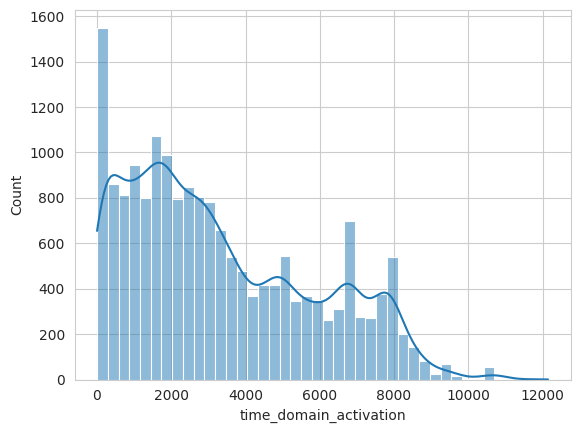

In [ ]:
# Code for Histograms



# Plot histogram
sns.histplot(data = df, x = "time_domain_activation", kde = True)


---

#### Histogram Questions:

1. Review the features in the dataset and identify 3 features that have an interesting distribution. Give a short explaination for each.

**[insert answer]**

2. Why is it innefective to do a histogram on a feature that represents a binary value?

**[insert answer]**

3. Run a histogram for the target variable 'phishing'. Does this reveal any data information about how balanced our data set is?

---

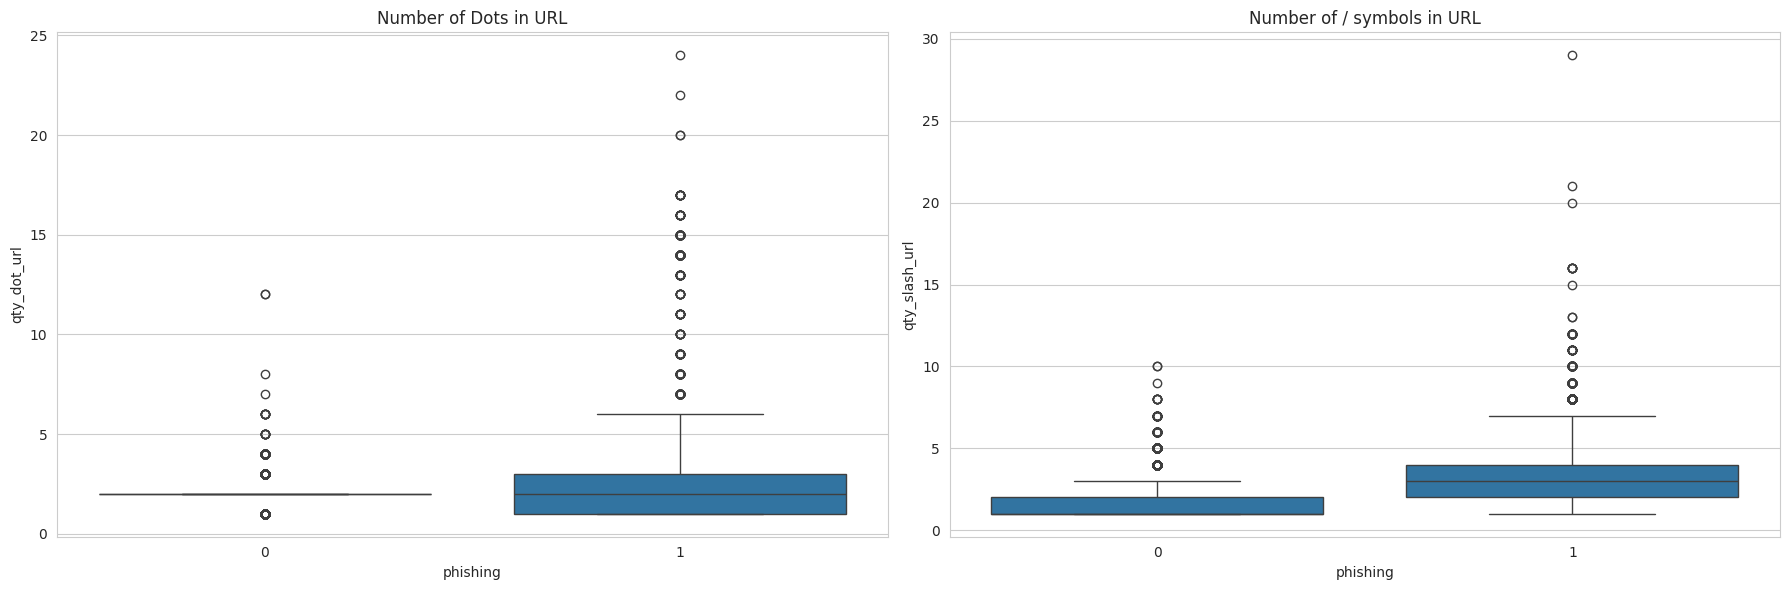

In [ ]:
#Box Plots

target_col = 'phishing'

plt.figure(figsize=(18, 6))

# Plot 1: length_url vs. target_col
plt.subplot(1, 2, 1)
sns.boxplot(x=target_col, y='qty_dot_url', data=df)
plt.title('Number of Dots in URL')

# Plot 2: domain_length vs. target_col
plt.subplot(1, 2, 2)
sns.boxplot(x=target_col, y='qty_slash_url', data=df)
plt.title('Number of / symbols in URL')

plt.tight_layout()
plt.show()

---

#### Box Plot Questions:

1. Based on the box plots for `qty_slash_url` and `qty_dot_url`, is there a noticeable difference in the median values between phishing and non-phishing URLs?

**[insert answer]**

2. Do either of the box plots show a significant number of outliers? What might this suggest about the data?

**[insert answer]**

3. For which feature (`qty_dot_url` or `qty_slash_url`) does the box plot seem to indicate a clearer separation between the two classes? Why do you think this is the case?

**[insert answer]**



---

###Recap of Histograms and Box Plots

From the histograms and box plots, we can observe the following:

* **Histograms:** Provided insights into the distribution of individual features. For example, the histogram for `time_domain_activation` (after filtering out -1 values) showed a skewed distribution. We also noted that features with binary values are not well-suited for histograms. You were asked to identify 3 features with interesting distributions and run a histogram on the 'phishing' target variable.
* **Box Plots:** Were useful for comparing the distribution of features across the two classes (`phishing` and non-`phishing`). The box plots for `qty_dot_url` and `qty_slash_url` showed potential differences in the distribution of these features between phishing and non-phishing URLs, suggesting they might be useful for classification. The presence of outliers in the box plots also highlights potential data points that warrant further investigation.
* **Note:** You will see more complex setting customization for histograms and/or box plots later in the course.

---
###8. Train-Test Split: Preparing for Model Evaluation

Before we delve deeper into correlation analysis or attempt to fix class imbalance, it's crucial to split our dataset into training and testing sets. This step is fundamental to building reliable machine learning models and preventing a phenomenon called **data leakage**.

**Why Train-Test Split is Essential:**

1.  **Preventing Data Leakage:** Data leakage occurs when information from the test set 'leaks' into the training process. For example, if we perform feature scaling, imputation of missing values, or even analyze correlations on the *entire* dataset before splitting, our model might inadvertently learn patterns from the test data. This leads to overly optimistic performance estimates on unseen data.

2.  **Evaluating Generalization:** The primary goal of a machine learning model is to generalize well to new, unseen data. By training on one subset (the training set) and evaluating on a completely separate subset (the test set), we get an unbiased estimate of how our model will perform in the real world.

3.  **Simulating Real-World Scenarios:** In a real-world scenario, you would train your model on historical data and then deploy it to make predictions on future, unknown data. The train-test split simulates this process, with the training set representing historical data and the test set representing future data.

**Important Consideration: Timing of the Split**

It is vital to perform the train-test split *before* any data preprocessing steps that might introduce information from the test set into the training set. This includes techniques like:

*   **Missing Value Imputation:** If you calculate the mean/median for imputation on the entire dataset, the test set's statistics influence the training set.
*   **Feature Scaling (e.g., Standardization, Normalization):** Calculating scaling parameters (mean, standard deviation) on the full dataset leads to data leakage.
*   **Oversampling (e.g., SMOTE):** As we'll discuss later, SMOTE should *only* be applied to the training set to prevent synthetic samples from influencing the test set evaluation.

By splitting first, we ensure that all preprocessing steps are learned *only* from the training data and then applied independently to the test data, maintaining the integrity of our model evaluation.

```
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('phishing', axis=1)
y = df['phishing']

# Perform the train-test split
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original dataset shape: {df.shape}")
print(f"Training set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Testing set shape (X_test, y_test): {X_test.shape}, {y_test.shape}")

# 1. Combine X_train and y_train for analysis
#    axis=1 tells pandas to join them side-by-side (as columns)
train_df = pd.concat([X_train, y_train], axis=1)

# 2. Combine X_test and y_test for ease of access

test_df = pd.concat([X_test, y_test], axis=1)

```

In [ ]:
# Run code here
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('phishing', axis=1)
y = df['phishing']

# Perform the train-test split
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original dataset shape: {df.shape}")
print(f"Training set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Testing set shape (X_test, y_test): {X_test.shape}, {y_test.shape}")

# 1. Combine X_train and y_train for analysis
#    axis=1 tells pandas to join them side-by-side (as columns)
train_df = pd.concat([X_train, y_train], axis=1)

# 2. Combine X_test and y_test for ease of access

test_df = pd.concat([X_test, y_test], axis=1)

Original dataset shape: (18070, 73)
Training set shape (X_train, y_train): (14456, 72), (14456,)
Testing set shape (X_test, y_test): (3614, 72), (3614,)


---

###8. Finding Relationships: Correlation Analysis

Next, we need to understand how our features relate to each other. Correlation measures how two variables move together. As we saw in Module 2, this is critical for two main reasons:

* Finding Redundant Features: If two features are almost perfectly correlated (e.g., qty_dot_url and length_url), they might be telling the model the same story. Keeping both can be redundant.

* Finding Strong Predictors: If a feature is highly correlated with our target variable (phishing), it's a strong sign that it will be a very useful predictor for our model.

**Pearson vs. Spearman Correlation**

When we run .corr(), we are (by default) using the Pearson correlation coefficient. This method is excellent at finding linear relationships (a perfect straight line).

However, what if the relationship isn't a straight line? What if a feature makes a URL more likely to be phishing, but the effect levels off? This is a monotonic relationship, and to find it, we use Spearman Rank Correlation.

* **Pearson: Measures how well data fits a straight line.**

* **Spearman: Measures how well data follows a monotonic trend (if one variable goes up, the other consistently goes up or down, but not necessarily in a straight line).**

We will check both. A Heatmap is a good way to visualize the full matrix, but with 73 features, it can be unreadable. A more practical technique, which we will also do, is to simply extract the correlation values for our target variable and sort them.



Generating Pearson (Linear) correlation heatmap...


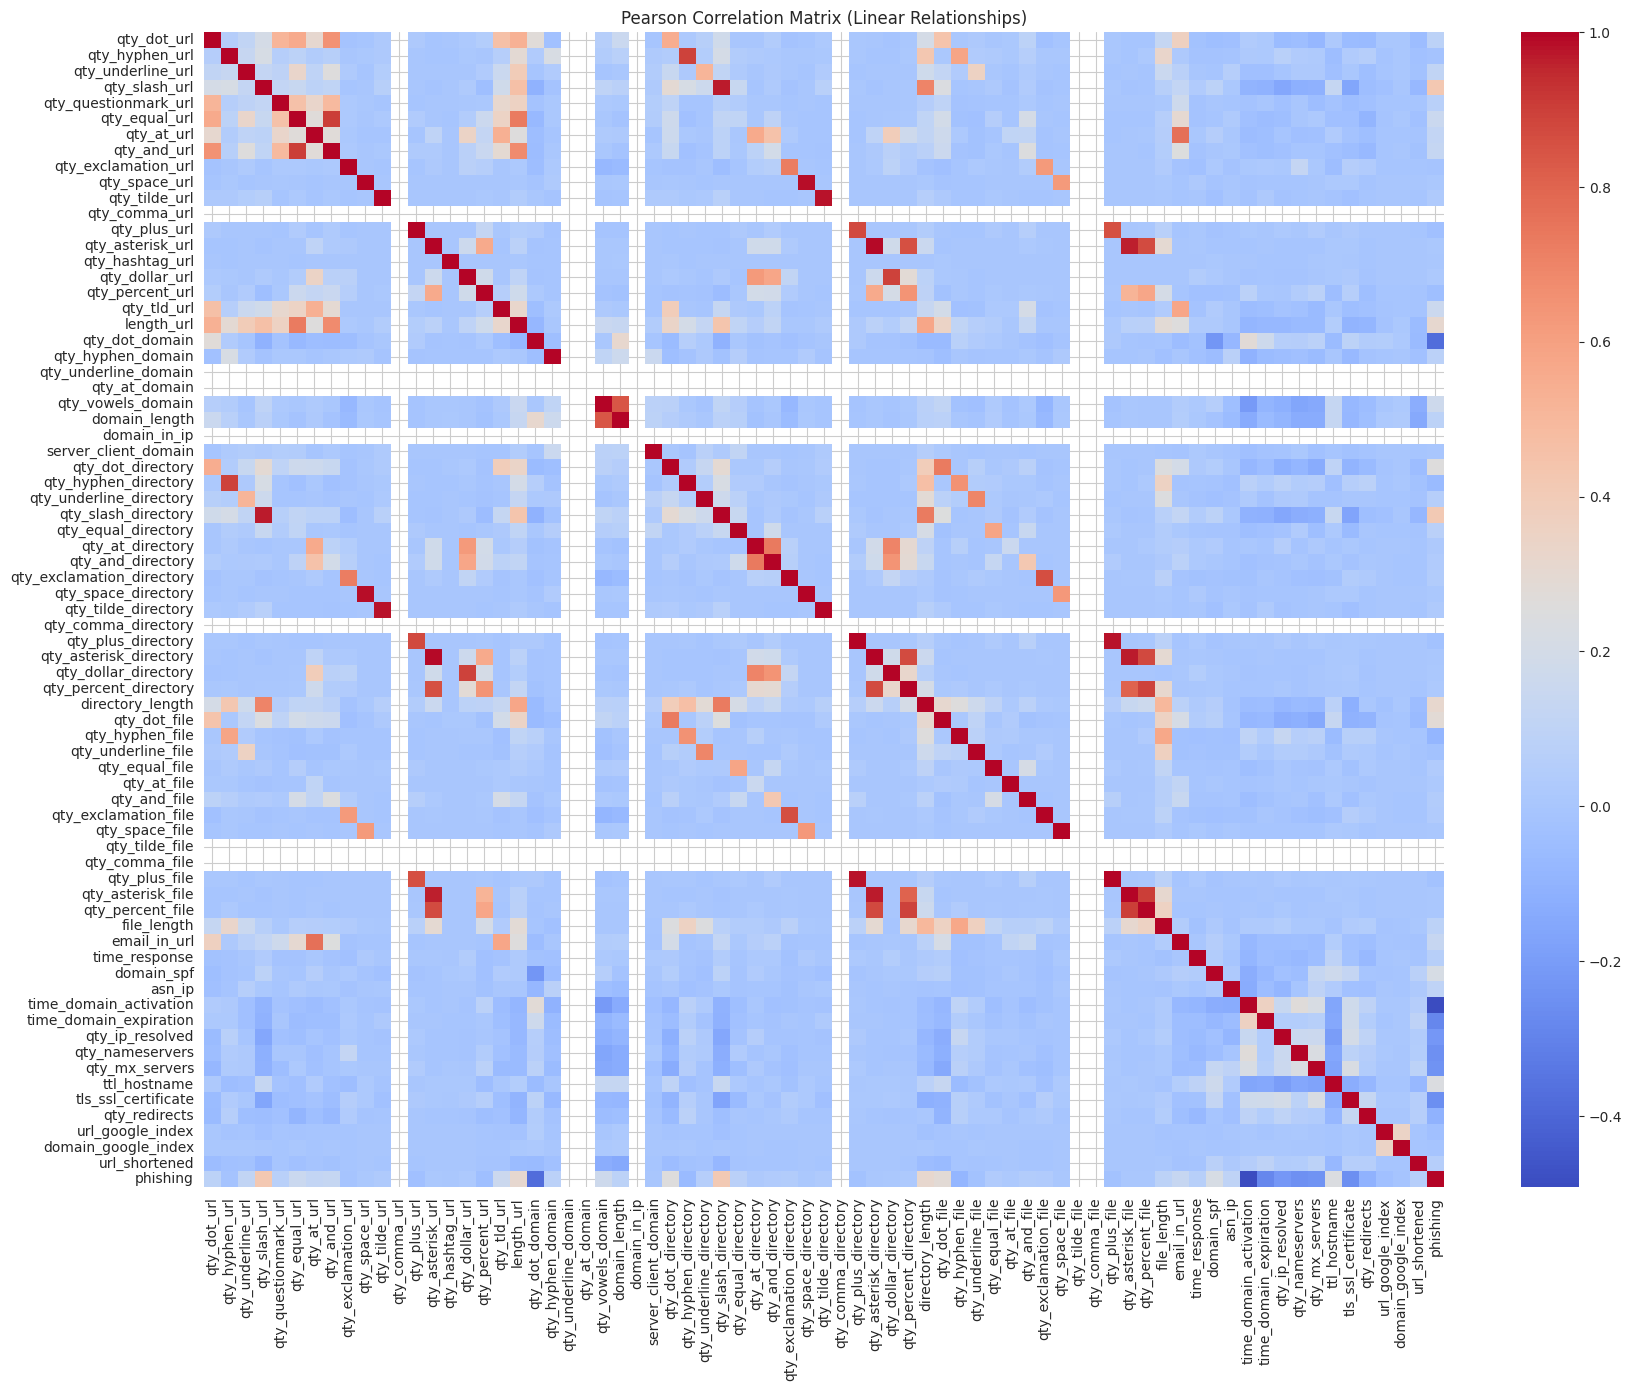

In [ ]:
# Code for Correlation Heatmap (Pearson)

print("Generating Pearson (Linear) correlation heatmap...")

# 1. Calculate the Pearson correlation matrix
corr_matrix_pearson = train_df.corr(method='pearson', numeric_only=True)

# 2. Plot the heatmap
plt.figure(figsize=(20, 15)) # May need to be even larger for 100+ features

# --- NOTE ---
# With 100+ features, 'annot=True' will create an unreadable mess.
# We set annot=False and will use a more targeted method below.
sns.heatmap(corr_matrix_pearson, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix (Linear Relationships)')
plt.show()

---

# I WANT A VIDEO DETAILING THE DIFFERENCE BETWEEN PEARSON AND SPEARMAN CORROLATION.

In [ ]:
# Code for Finding Top Predictors (A More Practical Method)

print("Calculating correlations with the target variable...")


target_col = 'phishing'

corr_matrix_pearson = train_df.corr(method='pearson', numeric_only=True)

# 1. Calculate Spearman (Monotonic) correlations
# We create a new matrix for this calculation
corr_matrix_spearman = train_df.corr(method='spearman', numeric_only=True)

# 2. Extract and sort the correlations for JUST our target variable
# This is much more readable than a giant heatmap!

# Get Pearson correlations with the target for positive corrolation
corr_pearson_target_pos = corr_matrix_pearson[target_col].sort_values(ascending=False)

# Get Pearson correlations with the target for negative corrolation
corr_pearson_target_neg = corr_matrix_pearson[target_col].sort_values(ascending=True)

# Get Spearman correlations with the target
corr_spearman_target = corr_matrix_spearman[target_col].sort_values(ascending=False)


print("\n--- Top 10 Features (Pearson Linear Correlation Positive Corrolation) ---")
# .drop(target_col) removes the 1.00 correlation with itself
print(corr_pearson_target_pos.drop(target_col).head(10))

print("\n--- Top 10 Features (Pearson Linear Correlation Negative Corrolation) ---")
# .drop(target_col) removes the 1.00 correlation with itself
print(corr_pearson_target_neg.drop(target_col).head(10))

print("\n--- Top 10 Features (Spearman Monotonic Correlation) ---")
print(corr_spearman_target.drop(target_col).head(10))

# By comparing these two lists, we can find features that are strong predictors
# in both a linear and non-linear way.


Calculating correlations with the target variable...

--- Top 10 Features (Pearson Linear Correlation Positive Corrolation) ---
qty_slash_url          0.417590
qty_slash_directory    0.416040
directory_length       0.316879
length_url             0.308517
qty_dot_file           0.285744
qty_dot_directory      0.257756
ttl_hostname           0.237012
domain_spf             0.215198
qty_vowels_domain      0.172326
qty_tld_url            0.155673
Name: phishing, dtype: float64

--- Top 10 Features (Pearson Linear Correlation Negative Corrolation) ---
time_domain_activation   -0.492014
qty_dot_domain           -0.379941
time_domain_expiration   -0.286023
tls_ssl_certificate      -0.253701
qty_nameservers          -0.249741
qty_mx_servers           -0.237769
qty_ip_resolved          -0.221397
qty_redirects            -0.103814
qty_hyphen_file          -0.088418
qty_hyphen_directory     -0.062810
Name: phishing, dtype: float64

--- Top 10 Features (Spearman Monotonic Correlation) ---
qty_sla

* * *

### Recap of Correlation Analysis and Questions:

From the correlation analysis, we observed the following:

*   The Pearson correlation heatmap showed the linear relationships between all features. With 73 features, the heatmap was dense, highlighting the need for more targeted analysis.
*   By extracting and sorting the correlations with the target variable (`phishing`), we identified the top features that have the strongest positive and negative linear (Pearson) and monotonic (Spearman) relationships with the target.
*   Comparing the top features from both Pearson and Spearman correlations helps us understand which features are strong predictors, whether their relationship with the target is linear or non-linear.

#### Correlation Analysis Questions:

1.  Based on the "Top 10 Features" lists for Pearson and Spearman correlations (both positive and negative), are there any features that appear in multiple lists? What does this suggest about their relationship with the `phishing` target variable?

**[insert answer]**

2.  Are there any features that appear in one list but not others? What might this indicate about the nature of their relationship with the `phishing` target variable (linear vs. monotonic, positive vs. negative)?

**[insert answer]**

3.  Looking at the top positively and negatively correlated features, do any of them intuitively make sense as strong indicators of a phishing URL? Why or why not?

**[insert answer]**

4.  The heatmap itself was difficult to read due to the number of features. What are some other ways you could visualize the correlation matrix for a large number of features to make it more interpretable?

**[insert answer]**



###9. Finding the Top 25 Most Correlated Feature Pairs

Goal: Now that we've found features that predict our target, we need to check for features that are highly correlated with each other. If two features are almost perfectly correlated, they are essentially telling the model the same information, which makes them redundant.

Your Task: The code below is a bit more advanced. It will:

Calculate the Pearson correlation matrix, just like before.

"Unpivot" the matrix into a long list of all possible pairs.

Clean up this list to remove duplicates (e.g., (A, B) is the same as (B, A)) and self-correlations (e.g., (A, A)).

Sort the list to find the top 25 pairs with the highest (most positive or most negative) correlation.

Run the code and then answer the follow-up questions.

In [ ]:
# Code for Finding Top 25 Correlated Feature Pairs (Improved Method)
import numpy as np

print("Finding the top 25 most correlated feature pairs...")

# make a temp df without the target variable
df_temp = train_df.drop(columns=['phishing'])

# 1. Get the Pearson correlation matrix
corr_matrix = df_temp.corr(method='pearson', numeric_only=True).abs()

# 2. Create a "mask" to hide the upper triangle of the matrix
# (k=1 ensures we also hide the diagonal, which is all 1.0s)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# 3. Apply the mask to the matrix
corr_matrix_masked = corr_matrix.where(mask)

# 4. "Unstack" the matrix into a Series, which makes it a long list of pairs,
#    drop the resulting NaN values, and sort
top_pairs = corr_matrix_masked.unstack().dropna().sort_values(ascending=False)

# 5. Print the results in a readable format
print("\n--- Top 25 Most Correlated Feature Pairs ---")
print(top_pairs.head(25))

print("\n--- Bottom 25 Most Correlated Feature Pairs ---")
print(top_pairs.tail(25))

# All Correlated Feature Pairs except for phising to a file
top_pairs.to_csv('top_correlated_pairs.csv')
files.download('top_correlated_pairs.csv')




Finding the top 25 most correlated feature pairs...

--- Top 25 Most Correlated Feature Pairs ---
qty_hashtag_file       qty_questionmark_file         1.000000
                       qty_hashtag_directory         1.000000
qty_dollar_file        qty_questionmark_directory    1.000000
qty_hashtag_file       qty_questionmark_directory    1.000000
                       qty_slash_file                1.000000
qty_hashtag_directory  qty_questionmark_directory    1.000000
qty_dollar_file        qty_hashtag_directory         1.000000
                       qty_slash_file                1.000000
                       qty_questionmark_file         1.000000
                       qty_hashtag_file              1.000000
qty_questionmark_file  qty_questionmark_directory    1.000000
                       qty_slash_file                1.000000
                       qty_hashtag_directory         1.000000
qty_slash_file         qty_hashtag_directory         1.000000
                       qty_questio

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

* * *

### Difference Between Target Correlation and Feature Pair Correlation

We have performed two types of correlation analyses:

1.  **Correlation with the Target Variable:** This analysis focused on finding which individual features have the strongest linear (Pearson) and monotonic (Spearman) relationships with our target variable (`phishing`). This helps us identify potential predictors that are most likely to be useful for our machine learning model.

2.  **Correlation Between Feature Pairs:** This analysis focused on finding pairs of features that are highly correlated with each other either positively or negatively **(this is called Absolute Corrolation).** This helps us identify redundant features. If two features have a very high absolute corrolation, they are providing very similar information to the model. In such cases, we might consider removing one of them to simplify the model and potentially improve performance and interpretability.

In summary, the first analysis helps us select features that are good predictors of the target, while the second analysis helps us identify and potentially remove features that are redundant.

---

###How to Handle Highly Correlated Features

You've just run a lab that found the "Top 25 Most Correlated Feature Pairs." This is a critical step in a real-world machine learning workflow. Now you're faced with an important decision: what do you do with this information?

If two features are very strongly correlated, they are essentially telling the model the same story, a problem called **multicollinearity**. Keeping both can be redundant and, in some cases, can make your model less stable and harder to interpret.

**The Rule of Thumb**

A common industry threshold is:

* If the (absolute) correlation between two features is very high (e.g., > 0.85 or 0.9), they are considered "highly correlated" and are likely redundant. You should consider removing one of them.

* This applies to both positive (+0.9) and negative (-0.9) correlations, as both represent a very strong predictive relationship.

**The Decision: "Which one do I remove?"**

* Don't just remove one at random! The best practice is to keep the feature that is a better predictor of your target variable (e.g., phishing).

* To do this, you compare the absolute correlation (the strength of the signal, ignoring the positive or negative sign) of each feature with the target.

####Here is a step-by-step decision-making process:

**Step 1: Identify the Redundant Pair**

* From your "Top 25" list, you find a pair:

* `feature_A` and `feature_B` have a 0.95 correlation.

**Step 2: Check Their Predictive Power**

* Now, you look back at your other list (the "Top 10 Predictors" that showed correlation with the target variable, phishing):

* Correlation between `feature_A` and phishing is is -0.6 (A strong negative predictor).

* Correlation between `feature_B` and phishing is +0.4 (A weaker positive predictor).

**Step 3: Make the Decision**

* The Decision: You would keep `feature_A` (because its absolute correlation of 0.6 is stronger than 0.4) and drop `feature_B` (because it's redundant and a weaker predictor).

This process ensures that you simplify your model by removing redundant data while keeping the features that have the most predictive power, regardless of whether their relationship is positive or negative.

---

###Lab Activity: Automating Feature Selection

**Objective:** To write a more advanced function that automatically removes highly correlated features based on a set of rules. This is a very common task for a data scientist.

**The Goal: We want to write a function that will:**

1. Select a specific correlation threshold **(Use: 0.9, 0.8, 0.7, and 0.6)**.

2. At each threshold, find all pairs of features that are more correlated than the threshold.

3. For each of those pairs, it must intelligently decide which feature to drop based on our rule: "Drop the feature that has the weaker correlation with the target variable (phishing)."

This will leave us with a final, "clean" list of features that are not redundant.

**Your Guided Task:**

Below is the "scaffolding" for this function. Your task is to read the 4 TODO comments and write the missing lines of code.



In [ ]:
import numpy as np
# --- NEW: Import the files module from google.colab ---
from google.colab import files

# --- Step 1: Set Your Experiment ---
# This is the *only* line you need to change.
# Try 0.9, then re-run with 0.8, 0.7, etc.
YOUR_THRESHOLD_HERE = 0.6

# --- TODO: Update 'phishing' if your target column has a different name ---
target_col = 'phishing'


# --- Setup (Provided for you) ---
print(f"--- Running feature selection for threshold: {YOUR_THRESHOLD_HERE} ---")

# 1. TODO 1: The correlation matrix for all features (Pearson)
corr_matrix = df.corr(method='pearson', numeric_only=True).abs()


# 2. The correlation series for just the target variable
corr_with_target = train_df.corr(method='pearson', numeric_only=True)[target_col].abs()

# 3. This is the list of features we will "clean"
# It starts as all columns *except* our target variable
features_to_keep = set(train_df.drop(columns=[target_col]).columns)
# --- MODIFIED: We no longer need the 'features_to_drop' set ---

print(f"Starting with {len(features_to_keep)} features.")

# --- Step 2: Main Loop ---
# We loop through all columns in our correlation matrix
# We iterate over a copy (.copy()) because we will be modifying the set during the loop
for col in corr_matrix.columns:

    # TODO 2: If 'col' was already removed (because it was weaker than another feature), this will be false, and we skip this entire iteration.

    if col not in features_to_keep:
        continue

    # TODO 3: Get all correlations for this one column
    correlations = corr_matrix[col]


    # Find features that are highly correlated (above the threshold)
    # and are NOT the same feature
    highly_corr_features = correlations[
        (correlations > YOUR_THRESHOLD_HERE) & (correlations.index != col)
    ].index

    # Now we loop through the list of correlated features we found
    for correlated_feature in highly_corr_features:
        # This check is also now effective:
        # If 'correlated_feature' was already dropped in a previous loop,
        # we skip this comparison.
        if correlated_feature not in features_to_keep:
            continue

        # --- Step 3: Make the Decision  ---

        # 1. Get the target correlation for 'col'
        col_target_corr = corr_with_target[col]

        # 2. Get the target correlation for 'correlated_feature'
        feature_target_corr = corr_with_target[correlated_feature]

        # 3. Make the decision and *immediately* remove the weaker feature
        print("Comparing", col, "and", correlated_feature)
        print("  > Target correlation for", col, "is", col_target_corr)
        print("  > Target correlation for", correlated_feature, "is", feature_target_corr)

        if col_target_corr < feature_target_corr:
            # 'col' is weaker, so we remove it *from features_to_keep*
            print("  > Dropping", col, "because it has a weaker correlation with the target.")
            features_to_keep.remove(col)
            # --- NEW: ---
            # Since we've dropped 'col', there's no need to compare it
            # to any other features. We break this inner loop
            # and move to the next 'col'.
            break
        else:
            # 'correlated_feature' is weaker, so we remove it *from features_to_keep*
            print("  > Dropping", correlated_feature, "because it has a weaker correlation with the target.")
            features_to_keep.remove(correlated_feature)


# --- Final Step: Review Results ---
print("\n--- Feature Selection Complete ---")
print(f"Original feature count: {len(train_df.columns) - 1}")
print(f"Final feature count: {len(features_to_keep)}")

final_features_list = list(features_to_keep)
print("\nFinal list of features to keep:")
print(final_features_list)

# --- Save and Download the New Datasets ---

# TODO 4: Add the target column back to our list so it's included in the new files
final_features_list_with_target = final_features_list + [target_col]


# Create the new DataFrame with only the selected features
df_final_train = train_df[final_features_list_with_target].copy()

# Edit test_df to reflect the changes to the list of features
df_final_test = test_df[final_features_list_with_target].copy()


# Create a dynamic filenames based on the threshold
output_filename_train = f"features_at_{YOUR_THRESHOLD_HERE}_threshold_train.parquet"

output_filename_test = f"features_at_{YOUR_THRESHOLD_HERE}_threshold_test.parquet"

# Save the new DataFrames to a Parquet files
df_final_train.to_parquet(output_filename_train, index=False)

df_final_test.to_parquet(output_filename_test, index=False)

print(f"\nNew dataset with {len(final_features_list)} features saved to '{output_filename_train}'.")
print("Triggering browser download...")

print(f"\nNew dataset with {len(final_features_list)} features saved to '{output_filename_test}'.")
print("Triggering browser download...")

# Trigger the download of the file to your local machine
files.download(output_filename_train)
files.download(output_filename_test)

--- Running feature selection for threshold: 0.6 ---
Starting with 72 features.
Comparing qty_dot_url and qty_and_url
  > Target correlation for qty_dot_url is 0.086681035077242
  > Target correlation for qty_and_url is 0.12792259305964782
  > Dropping qty_dot_url because it has a weaker correlation with the target.
Comparing qty_hyphen_url and qty_hyphen_directory
  > Target correlation for qty_hyphen_url is 0.014559346479412278
  > Target correlation for qty_hyphen_directory is 0.06280957960505056
  > Dropping qty_hyphen_url because it has a weaker correlation with the target.
Comparing qty_slash_url and qty_slash_directory
  > Target correlation for qty_slash_url is 0.41759002622040026
  > Target correlation for qty_slash_directory is 0.41603992619115265
  > Dropping qty_slash_directory because it has a weaker correlation with the target.
Comparing qty_slash_url and directory_length
  > Target correlation for qty_slash_url is 0.41759002622040026
  > Target correlation for directory_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title
# Answers:

# TODO 1:
corr_matrix = df.corr(method='pearson', numeric_only=True).abs()

# TODO 2:
if col not in features_to_keep:
    continue

# TODO 3:
correlations = corr_matrix[col]

# TODO 4:
final_features_list_with_target = final_features_list + [target_col]


### 10. A Deep Dive on Model Metrics: Why Accuracy is a Trap

In the last lab, your countplot visualization almost certainly confirmed a critical fact of life in cybersecurity: our data is severely imbalanced. You likely saw a massive bar for "Benign" or "Legitimate" traffic and tiny, barely visible bars for your "Phishing" or "Attack" classes.

This isn't just a "data problem"; it's the #1 reason that new data scientists build useless security models.

**The Accuracy Trap**

Imagine a dataset with 10,000 log entries, where 9,900 are "Benign" and 100 are "Attacks." A machine learning model is lazy. It can achieve 99% accuracy by learning a very simple, stupid rule:

*Always predict 'Benign'*.

* The model is technically "correct" 99% of the time, but it has learned nothing about how to spot a threat. It has completely failed its one real job. This is the Accuracy Trap.

* To get out of this trap, we have to stop using "Accuracy" as our main metric and start using a more sophisticated "magnifying glass" that tells us where our model is making mistakes.

**The Magnifying Glass: The Confusion Matrix**

A Confusion Matrix is the single best tool for understanding a classifier's performance. It's a simple grid that breaks down all of our test predictions into four categories:

* True Positive (TP): The model predicted "Phishing," and the URL was "Phishing." (A successful catch!)

* True Negative (TN): The model predicted "Benign," and the URL was "Benign." (A correct rejection.)

* False Positive (FP) (Type I Error): The model predicted "Phishing," but the URL was "Benign." (A false alarm. This annoys users or analysts.)

* False Negative (FN) (Type II Error): The model predicted "Benign," but the URL was "Phishing." (A catastrophic failure. The attack gets through.)

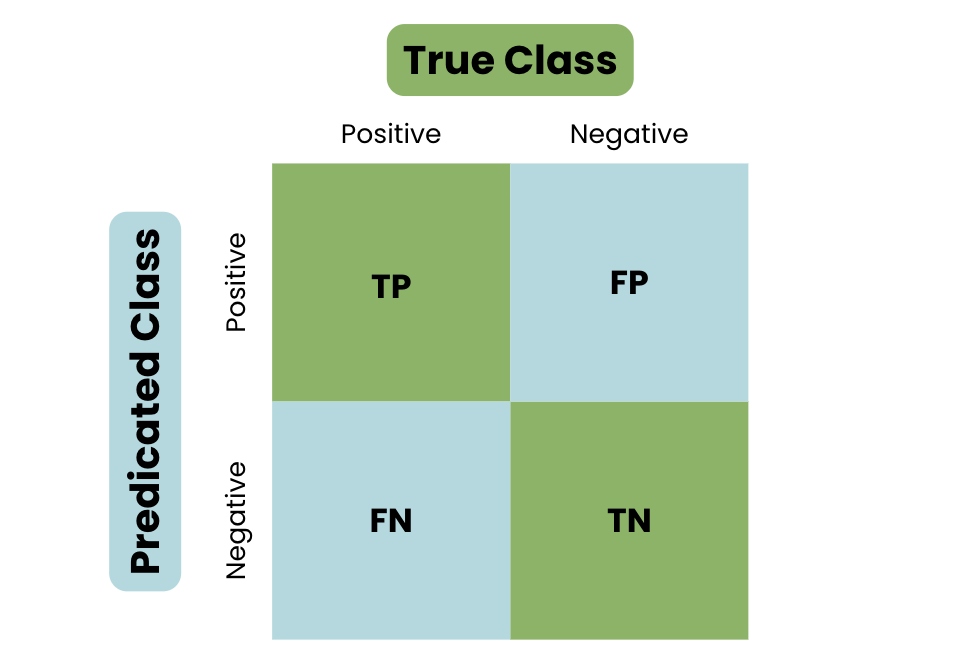

**The Key Metrics: Precision, Recall, and F1-Score**

From these four numbers, we get the three most important metrics for classification.

**Precision: The "False Alarm" Metric**

Question: "Of all the alerts the model generated, how many were actually malicious?"

Formula: ```TP / (TP + FP)```

Why it Matters: High precision means your model is trustworthy. When it flags something, your analysts know it's worth investigating. Low precision means the model is "the boy who cried wolf," flooding your team with false positives until they start ignoring its alerts completely.

**Recall: The "Catch Rate" Metric**

Question: "Of all the real attacks that happened, how many did our model catch?"

Formula: ```TP / (TP + FN)```

Why it Matters: High recall means your model is effective at its job. It's finding the needles in the haystack. Low recall means your model is letting threats slip through the net, which is the worst possible outcome.

**F1-Score: The "Balanced" Metric**

Question: "How can I get a single score that balances the trade-off between Precision and Recall?"

Formula: ```2 * (Precision * Recall) / (Precision + Recall)```

**Why it Matters:** The F1-Score is the harmonic mean of Precision and Recall. It gives you a single, combined score. More importantly, it severely punishes models that are extremely one-sided. A model with 100% Precision but 1% Recall will have a terrible F1-Score, which correctly tells you it's a useless model.

**The Advanced Metric: ROC-AUC**

Finally, there is one more advanced metric that is critical for comparing models: the ROC-AUC Score.

* ROC (Receiver Operating Characteristic) Curve: This is a graph that plots the True Positive Rate (Recall) against the False Positive Rate at every possible threshold. A model that is a perfect classifier would have a curve that goes straight up the left side and across the top.

* AUC (Area Under the Curve): This is the metric we care about. It calculates the entire area under that ROC curve and gives you a single score between 0.5 and 1.0.

**1.0: A perfect model that can perfectly distinguish between the two classes.**

**0.5: A useless model that is no better than random guessing.**

The AUC score is the single best measure of a model's overall ability to distinguish between "Phishing" and "Benign".

**The Analyst's Dilemma: The Trade-Off**

You will almost never have 100% Precision and 100% Recall. There is always a trade-off.

* To get 100% Recall, you could build a model that flags everything as "suspicious." You'd catch every threat, but your Precision would be 1%, and your analyst team would quit.

* To get 100% Precision, you could build a model that only flags an attack it is 100.00% sure about. Your alerts would be perfect, but your Recall would be 5%, and you'd miss all the new, subtle attacks.

The "right" balance depends on the business. For a spam filter, you might favor Precision (don't flag a legitimate email as spam). For detecting ransomware, you must favor Recall (you're willing to accept a few false alarms to avoid a catastrophic breach).


* * *
### 11. Visualizing Class Imbalance: Count Plots

In many real-world classification problems, especially in cybersecurity, the classes are not evenly distributed. This is known as **class imbalance**. For example, in a dataset of website URLs, there will be far fewer malicious (phishing) URLs than legitimate ones.

Why is this a problem? If a machine learning model is trained on an imbalanced dataset, it can become biased towards the majority class. It might achieve high overall accuracy by simply predicting the majority class for every input, while completely failing to identify the rare, but often more important, minority class (e.g., the phishing attacks). This is known as the **Accuracy Trap**.

To avoid the Accuracy Trap, it's crucial to visualize and understand the extent of class imbalance in your dataset before building models. A simple yet effective way to do this is by using a **count plot**.

A count plot (from the seaborn library) shows the number of observations in each categorical bin. By creating a count plot for our target variable (`phishing`), we can quickly see the distribution of the two classes (phishing and non-phishing) and visually confirm if our dataset is imbalanced.

**IMPORTANT: Run this visualization for each of the corrolation threshhold DataFrames that you created (Original, 0.9, 0.8, 0.7, 0.6). make sure to import your DF as 'train_df' each time or edit the code below to use the correct DF name.**

Generating count plot for the target variable 'phishing'...


/tmp/ipython-input-632417130.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='phishing', data=train_df, palette='viridis')


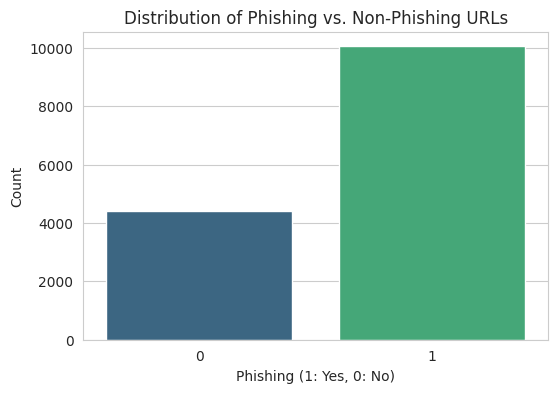


Value Counts for the target variable 'phishing':
phishing
1    10050
0     4406
Name: count, dtype: int64


In [ ]:
# Code for Count Plot of Target Variable

print("Generating count plot for the target variable 'phishing'...")

# Use seaborn's countplot to visualize the distribution of the target variable
plt.figure(figsize=(6, 4)) # Adjust figure size as needed
sns.countplot(x='phishing', data=train_df, palette='viridis')
plt.title('Distribution of Phishing vs. Non-Phishing URLs')
plt.xlabel('Phishing (1: Yes, 0: No)')
plt.ylabel('Count')
plt.show()

# Also print the value counts to see the exact numbers
print("\nValue Counts for the target variable 'phishing':")
print(train_df['phishing'].value_counts())

### Recap of Class Imbalance and Questions:

The count plot and value counts for the `phishing` target variable have clearly shown that our datasets are imbalanced, with a much larger number of **phishing URLs (the majority class)** compared to **non-phishing URLs (the minority class)**. This visual confirmation is critical because training a model on such imbalanced data can lead to the "Accuracy Trap," where the model performs poorly at identifying the **minority class (non-phishing URLs)**, even if it has high overall accuracy.

Recognizing and addressing this imbalance is a crucial step before building effective classification models in cybersecurity.

#### Questions:

1.  Based on the count plot, approximately how many times more **phishing** URLs are there compared to **non-phishing** URLs in each data set?

**[insert answer]**

2.  Why is simply having high "accuracy" on these imbalanced datasets not a reliable indicator of a good model for detecting **non-phishing** URLs (the minority class)?

**[insert answer]**

3.  What potential problems might a machine learning model trained on this imbalanced data have when trying to identify rare **non-phishing** URLs?

**[insert answer]**

4.  Given this imbalance, what kind of strategies or techniques do you think we might need to employ to ensure our model can effectively learn to identify both **phishing (majority)** and **non-phishing (minority)** URLs?

**[insert answer]**

---



### 11. A Critical Problem: The Class Imbalance Trap

In the last lab, your countplot visualization almost certainly confirmed a critical fact of life in cybersecurity: our data is almost always severely imbalanced.

**Why Is This a "Trap"?**

This imbalance is the #1 problem that causes new data scientists to build useless security models.

* Why? Because a machine learning model is lazy. If you give it a dataset that is 99% benign and 1% attack, the model can achieve 99% accuracy by learning a very simple, stupid rule: "Always predict 'Benign'."

* The model is technically "correct" 99% of the time, but it has learned nothing about how to spot a threat. It has completely failed its one real job. This is the Accuracy Trap.

**How Do We Fix It?**

We cannot train a model on this raw, imbalanced data. We must force the model to pay attention to the rare, important "needle" in the haystack. To do this, we must rebalance our training data (never our test data!) before we train the model.

There are two common approaches to rebalancing the dataset:

1.  **Undersampling:** This method involves "balancing" the dataset by simply deleting random examples from the majority class (the 'Benign' class) until it's the same size as the minority class. This is fast, but you throw away a massive amount of potentially valuable data about what "normal" looks like.

2.  **Oversampling:** This is a much smarter and more common approach. Instead of deleting good data, we create new, synthetic data for the minority class (the 'Attack' class). The most popular and effective way to do this is called SMOTE.

**Our Approach in This Lab: Demonstrating Both Undersampling and Oversampling (SMOTE)**

In this lab, we will demonstrate both undersampling and oversampling (SMOTE) techniques. While oversampling with SMOTE is often preferred for retaining data richness, understanding undersampling is also crucial for a complete toolkit. We will proceed with SMOTE for our primary model training, but acknowledge both methods as viable strategies.

**SMOTE (Synthetic Minority Over-sampling Technique)**

SMOTE is a brilliant algorithm. It doesn't just copy the few attack examples you have. Instead, it "looks" at the existing attack examples in your training set and generates new, synthetic examples that are statistically similar but not identical to the ones it has already seen.

*   It's like creating "fake" phishing URLs that have similar characteristics to real phishing URLs.

*   By using SMOTE, we will create a new, perfectly balanced training dataset where the "Attack" class is just as common as the "Benign" class. When we train our models on this new, balanced data, the model can no longer get a high score by being lazy. It is forced to learn the real, subtle patterns that actually separate a threat from normal activity.

---

### Lab: Addressing Class Imbalance

**Run this lab with each of the threshold dataframes as 'train_df' and there corrosponding 'test_df' dataframes that you created from the "Automating Feature Selection" Lab (Original, 0.9, 0.8, 0.7, 0.6). Make sure to record your metrics in the text entry below for both the SMOTE and Undersampled model results.**

In [ ]:
# Import our essential libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE # This is our new library!

# Set the default style for our plots
sns.set_style('whitegrid')

# --- PREREQUISITE ---
# Verify that train_df and test_df are loaded
try:
    print(f"train_df shape: {train_df.shape}")
    print(f"test_df shape: {test_df.shape}")
except NameError:
    print("Error: 'train_df' or 'test_df' not found. Please run Lab A first.")

**Part 1: The "Naive" Model (Training on Imbalanced Data)**

First, let's establish our baseline. We will train a Logistic Regression model on our train_df as-is (imbalanced) and see how it performs. This is the "before" part of our experiment.

In [ ]:
target_col = 'phishing'

# 1. Create our X/y splits from the dataframes
X_train = train_df.drop(target_col, axis=1)
y_train = train_df[target_col]

X_test = test_df.drop(target_col, axis=1)
y_test = test_df[target_col]

# 2. Scale our features
# We fit the scaler ONLY on X_train, and transform BOTH
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train the "Naive" model
print("Training the 'Naive' model on IMBALANCED data...")
naive_model = LogisticRegression(random_state=42, max_iter=1000)
naive_model.fit(X_train_scaled, y_train)
print("Naive model trained.")

# 4. Evaluate the "Naive" model
print("\n--- Naive Model Performance (IMBALANCED Data) ---")
y_pred_naive = naive_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_naive))


**Analysis of the "Naive" Model**

Look at the classification_report printed above. You will see two things:

* High Overall Accuracy: The accuracy score will look very good, probably 90% or higher.

* Terrible Recall (for the minority class): Look at the recall score for your phishing class (e.g., class 1). It will be extremely low.

This is the Accuracy Trap in action. Our model is getting a high score by just guessing "Benign" (class 0) most of the time, and it's failing to do its real job: catching the phishing attacks.



**Part 2: The "Fix" - Applying SMOTE**

Now that we've proven we have a problem, let's fix it. We will use SMOTE (Synthetic Minority Over-sampling Technique) to create new, synthetic "phishing" examples, but only in our training set.

In [ ]:
# --- Applying SMOTE ---

print("Applying SMOTE to the (scaled) training data...")

# A critical step: SMOTE's 'k_neighbors' parameter must be
# less than the number of samples in the smallest class.
# This code automatically calculates the safe k-value.
min_class_count = y_train.value_counts().min()
k = max(1, min_class_count - 1)
print(f"Smallest class has {min_class_count} samples. Setting k_neighbors={k}.")

# 1. Initialize SMOTE
sm = SMOTE(random_state=42, k_neighbors=k)

# 2. Fit and resample the training data
# We give it our (scaled) imbalanced training data...
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_scaled, y_train)

# ...and it gives us new, balanced data.
print("SMOTE applied successfully.")
print(f"Original training shape: {X_train_scaled.shape}")
print(f"New 'balanced' training shape: {X_train_balanced.shape}")

**Visual Confirmation**

Let's "close the loop" and prove that our new y_train_balanced data is, in fact, balanced.

In [ ]:
# Code for Visual Confirmation Plot
print("Visualizing class distribution *after* SMOTE...")

plt.figure(figsize=(10, 6))
sns.countplot(x=y_train_balanced, order=pd.Series(y_train_balanced).value_counts().index)
plt.title('Class Distribution of Target Variable (After SMOTE)')
plt.xlabel('Threat Type')
plt.ylabel('Count')
plt.show()

**Part 3: The "Balanced" Model (Training on SMOTE Data)**

We now have a new, balanced training set. Let's train a new Logistic Regression model on this data and see what happens. We will evaluate it on the same, original, imbalanced X_test_scaled because we want to see how it performs in a real-world scenario.



In [ ]:
# 1. Train the "Balanced" model
print("Training the 'Balanced' model on SMOTE data...")
balanced_model = LogisticRegression(random_state=42, max_iter=1000)
balanced_model.fit(X_train_balanced, y_train_balanced) # Note: we use the new _balanced data
print("Balanced model trained.")

# 2. Evaluate the "Balanced" model on the original test set
print("\n--- Balanced Model Performance (TRAINED on SMOTE Data) ---")
y_pred_balanced = balanced_model.predict(X_test_scaled) # We still test on X_test_scaled
print(classification_report(y_test, y_pred_balanced))

**Part 4: The "Undersampling" Fix - Random Undersampling**

Another way to balance data is to simply remove examples from the majority class ("Benign") until it matches the size of the minority class.

* Pros: It's extremely fast and makes the dataset much smaller (easier to train).

* Cons: You throw away a huge amount of potentially valuable data.

In [ ]:
# --- Applying Random Undersampling ---

print("Applying Random Undersampling to the (scaled) training data...")

# 1. Initialize the RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# 2. Fit and resample the training data
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

print("Undersampling applied successfully.")
print(f"Original training shape: {X_train_scaled.shape}")
print(f"New 'Undersampled' training shape: {X_train_under.shape}")
# Note how much smaller the dataset is now!

**Part 5: The "Undersampled" Model**

Let's train a model on this smaller, balanced dataset and see how it compares.

In [ ]:
# 1. Train the "Undersampled" model
print("Training the model on Undersampled data...")
under_model = LogisticRegression(random_state=42, max_iter=1000)
under_model.fit(X_train_under, y_train_under)
print("Undersampled model trained.")

# 2. Evaluate the "Undersampled" model on the original test set
print("\n--- Model Performance (Undersampled Data) ---")
y_pred_under = under_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_under))


**Part 6: Final Experiment Analysis**

You have now completed the most advanced experiment in the course so far. You have:

1. Created multiple versions of your dataset, each one using a different correlation threshold to remove redundant features.

2. Trained a separate, balanced (with SMOTE) Logistic Regression model on each of those datasets.

3. Trained a Logistic Regression model on an undersampled, balanced, data set.

4. Generated a full set of performance metrics for each model.

Now it's time to be a data scientist and analyze the results. The final step is to consolidate your findings to find the "sweet spot" – the model that gives you the best performance with the fewest (and simplest) features.

**Consolidate Your Results**

Your goal is to complete the entries below. You will need to go back and look at the classification_report from each of your lab runs (for each threshold) to find the metrics for the phishing class.

###**Model trained on SMOTE Data:**

**Original (no filter)**:

\# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

**Threshold: 0.9**

/# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

**Threshold: 0.8**

/# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

**Threshold: 0.7**

/# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

**Threshold: 0.6**

/# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]



###**Model trained on Undersampled Data:**

**Original (no filter)**:

\# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

**Threshold: 0.9**

/# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

**Threshold: 0.8**

/# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

**Threshold: 0.7**

/# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

**Threshold: 0.6**

/# of Features Kept: [Your #]

F1-Score (phishing): [Your score]

Recall (phishing): [Your score]

Overall Accuracy: [Your score]

---

###Analysis Questions

Based on the data you just collected in your list, answer the following questions.

1. Analyze the Trend: What did you observe? As you removed more and more features (by lowering the correlation threshold), what happened to your Recall and F1-Score for the phishing class? Did they get better, worse, or stay about the same?

**[insert answer]**

2. Find the "Sweet Spot": Look at your list. Where is the "sweet spot"? Which threshold gave you the best (or a very close-to-best) F1-Score while using the fewest number of features?

**[insert answer]**

3. The "Most Features" Fallacy: Did the model with the most features (the "original" dataset) have the best performance? If not, why do you think removing features might have actually helped the model (or at least not hurt it)?

**[insert answer]**

4. Did the models trained on the SMOTE datasets always perform better than the models trained on the undersampled data?

**[insert answer]**

5. Business Recommendation: Imagine you had to present one of these models to your boss. Which one would you recommend? (e.g., "I recommend the 0.7-threshold model, because it performs 99% as well as the full model but is 50% simpler, making it faster and easier to maintain.")

**[insert answer]**




## Common Issues: Underfitting and Overfitting

As we build and train machine learning models, two common pitfalls we must be aware of are underfitting and overfitting. These concepts describe how well our model generalizes to new, unseen data, which is crucial for real-world application.

#### Underfitting

**What it is:** Underfitting occurs when a model is too simple to capture the underlying patterns in the training data. It fails to learn from the training data effectively, resulting in poor performance on both the training data and new data.

**Symptoms:**
*   Low accuracy/F1-score on the training data.
*   Low accuracy/F1-score on the test data.
*   The model is too simplistic (e.g., a linear model trying to fit complex non-linear relationships).

**Causes:**
*   Model is too simple (e.g., not enough features, low model complexity).
*   Insufficient training time or an overly aggressive regularization (though this is more common with overfitting).

**Solutions:**
*   Increase model complexity (e.g., use more features, choose a more complex algorithm like a Random Forest instead of Logistic Regression).
*   Reduce regularization.
*   Add more relevant features to the dataset.

#### Overfitting

**What it is:** Overfitting occurs when a model learns the training data too well, including its noise and random fluctuations. It essentially memorizes the training data rather than learning generalizable patterns. As a result, it performs exceptionally well on the training data but poorly on new, unseen data.

**Symptoms:**
*   Very high accuracy/F1-score on the training data.
*   Significantly lower accuracy/F1-score on the test data.
*   The model is overly complex and captures noise as if it were a pattern.

**Causes:**
*   Model is too complex (e.g., too many features, very deep decision trees).
*   Not enough training data to represent the underlying patterns adequately.
*   Lack of regularization.

**Solutions:**
*   Simplify the model (e.g., reduce the number of features, use simpler algorithms, prune decision trees).
*   Increase the amount of training data.
*   Use regularization techniques (e.g., L1 or L2 regularization in linear models, setting `max_depth` for decision trees, `n_estimators` for Random Forests, or C-parameter for SVMs).
*   Use cross-validation to get a more robust estimate of model performance.
*   Apply feature selection techniques (as we did with correlation thresholds) to remove redundant or irrelevant features.

In [ ]:
# @title

from IPython.display import IFrame

IFrame("https://www.youtube.com/watch?v=o3DztvnfAJg", width=900, height=600)

#Picture Credit: https://www.geeksforgeeks.org/machine-learning/supervised-vs-reinforcement-vs-unsupervised/

# Lab: Overfitting and Underfitting

Objective: Before we do the final evaluation with our test status set, we need to make sure that our model and the data we're using is not causing overfitting or underfitting.

In this lab, we will use Learning Curves to diagnose two common illnesses in machine learning models:

* Overfitting: The model is "hallucinating." It memorizes the training data perfectly but fails on new data.

* Underfitting: The model is "lazy." It is too simple to learn the complex patterns in the data.

The Diagnostic Tool: **Learning Curves**

**A learning curve plots the model's performance as we give it more and more training data.**

* Gap = Overfitting: If the Training Score is very high (near 1.0) but the Cross-Validation Score is low, there is a large "gap." This means the model is memorizing, not learning.

* Low Scores = Underfitting: If both scores are low and converged, the model just isn't powerful enough.

* Converged High Scores = Good Fit: If both scores are high and the gap is small, you have a healthy model!


**Step 1: Define the Plotting Function**

We will use a specialized library called Yellowbrick. It is an extension of scikit-learn designed specifically for visualizing machine learning performance. It does the hard work of plotting for us, so we can focus on the diagnosis.

**Important:** The data frames loaded into train_df and test_df should be cleaned and corrolation corrected based on the lab. But they should NOT have been SMOTEd or scaled in any way as the pipeline object takes care of this (it will mxake more sense once you look at the code).
```python
# Install the library in google colab
!pip install yellowbrick

# Import the Learning Curve visualizer
from yellowbrick.model_selection import LearningCurve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Yellowbrick installed and imported.")

# split the data

target_col = 'phishing'

# 1. Create our X/y splits from the dataframes
X_train = train_df.drop(target_col, axis=1)
y_train = train_df[target_col]

X_test = test_df.drop(target_col, axis=1)
y_test = test_df[target_col]


print("Data split.")

```
**Step 2: Select Your Contenders**


```python
# --- TODO: Instantiate your models here ---


from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


# Replace these with your actual winners!
# Run learnig curves on all four of the models.
model_1 = LogisticRegression(random_state=42, max_iter=1000)
model_2 = DecisionTreeClassifier(random_state=42) # Often a good example of overfitting
model_3 = RandomForestClassifier(random_state=42, n_estimators=100)
model_4 = SVC(kernel='linear', random_state=42)

print("Models ready for diagnosis.")
```

**Step 3: Run the Diagnostics**

* Now, let's generate the curves.

* This might take a minute, as it has to retrain the models multiple times on different subsets of data.

**Note: Make sure that the dataset is loaded into the google colab session.**

```python
# --- Diagnostic 1: Model 1 ---


# 1. Create the Pipeline


# 1. Scale the data (using only training stats)
# 2. SMOTE the data (using only training examples)
# 3. Fit the Model

pipeline1 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', model_1)
])

# Instantiate the visualizer with the model
# scoring='f1' tells it to track the F1-score (our key metric)
visualizer1 = LearningCurve(pipeline1, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer1.fit(X_train, y_train)

# Finalize and render the figure
visualizer1.show()


# --- Diagnostic 2: Model 2 ---

pipeline2 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', model_2)
])

visualizer2 = LearningCurve(pipeline2, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer2.fit(X_train, y_train)

# Finalize and render the figure
visualizer2.show()

# --- Diagnostic 3: Model 3 ---

pipeline3 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', model_3)
])

visualizer3 = LearningCurve(pipeline3, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer3.fit(X_train, y_train)

# Finalize and render the figure
visualizer3.show()

# --- Diagnostic 4: Model 4 ---

pipeline4 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', model_4)
])

visualizer4 = LearningCurve(pipeline4, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer4.fit(X_train, y_train)

# Finalize and render the figure
visualizer4.show()

```

**Step 4: Diagnosis & Analysis**

Look at the graphs you generated and answer the following questions:

1. Identify Overfitting: Look at the gap between the Training Curve and the Cross Validation Curve.

Does one model have a huge gap (e.g., Training is 1.0, but Validation is 0.85)?

If so, that model is Overfitting. It's memorizing the training set.

* Hint: Decision Trees often show this pattern.

2. Identify Underfitting: Look at the score values.

Do both lines converge to a low score (e.g., both are stuck at 0.70)?

If so, that model is Underfitting. It needs more complexity or better features.

**The "Healthy" Model:**

3. Which model has the best balance? You want a high Green line that is reasonably close to the Red line

Action Plan:

* If your best model is Overfitting, what could you do? (Hint: reducing max_depth in a tree, or getting more data—look at the x-axis trend!)

* If your best model is Underfitting, what could you do? (Hint: adding more complex features, or choosing a more complex model like Random Forest over Logistic Regression).

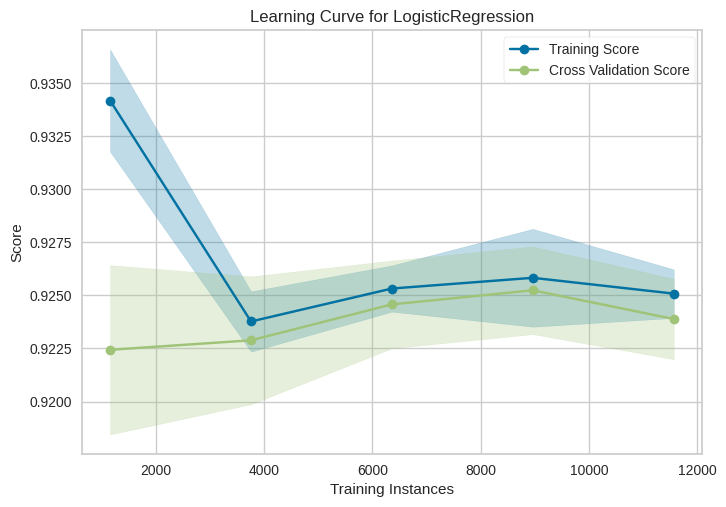

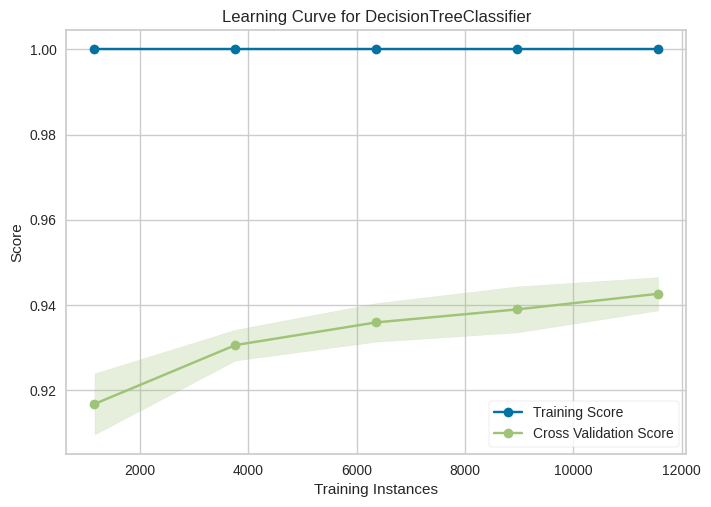

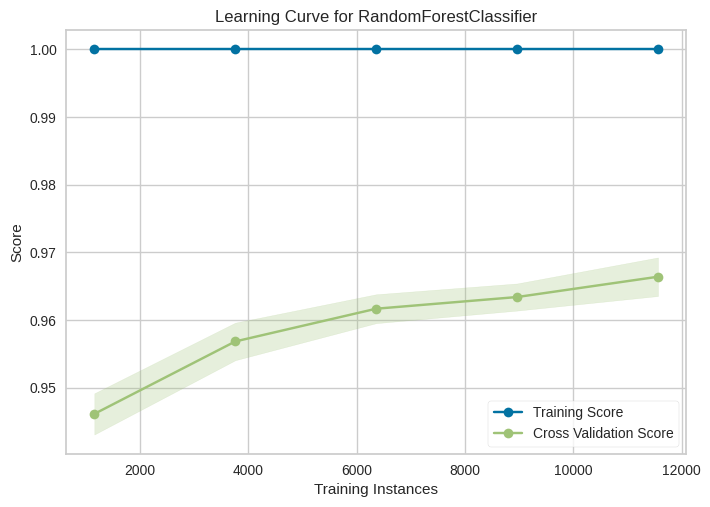

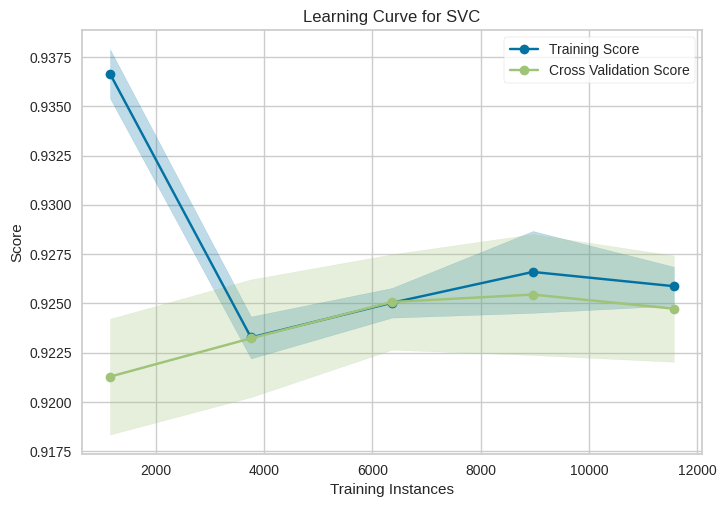

<Axes: title={'center': 'Learning Curve for SVC'}, xlabel='Training Instances', ylabel='Score'>

In [ ]:
# Run code here

# --- Diagnostic 1: Model 1 ---


# 1. Create the Pipeline


# 1. Scale the data (using only training stats)
# 2. SMOTE the data (using only training examples)
# 3. Fit the Model

pipeline1 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', model_1)
])

# Instantiate the visualizer with the model
# scoring='f1' tells it to track the F1-score (our key metric)
visualizer1 = LearningCurve(pipeline1, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer1.fit(X_train, y_train)

# Finalize and render the figure
visualizer1.show()


# --- Diagnostic 2: Model 2 ---

pipeline2 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', model_2)
])

visualizer2 = LearningCurve(pipeline2, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer2.fit(X_train, y_train)

# Finalize and render the figure
visualizer2.show()

# --- Diagnostic 3: Model 3 ---

pipeline3 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', model_3)
])

visualizer3 = LearningCurve(pipeline3, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer3.fit(X_train, y_train)

# Finalize and render the figure
visualizer3.show()

# --- Diagnostic 4: Model 4 ---

pipeline4 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', model_4)
])

visualizer4 = LearningCurve(pipeline4, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer4.fit(X_train, y_train)

# Finalize and render the figure
visualizer4.show()


# Lab Part 2: Tuning for the Final Test

**Objective:** In the previous section, we diagnosed our models. We found that LogisticRegression and SVC were underfitting (too simple), while DecisionTree and RandomForest were overfitting (too complex).

Now, we will use Hyperparameter Tuning to fix these issues. We will use GridSearchCV to systematically test different settings ("knobs") for each model to find the version that balances bias and variance best.

**We need to tune our models to fix the overfitting and underfitting we identified. Because we are dealing with imbalanced data, we must ensure our tuning process respects our Pipeline:**

* Scale (using training stats)

* SMOTE (create synthetic data only for training)

* Model (fit on the balanced, scaled data)

Prerequisites:


```python
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Common setup for all pipelines
# 'random_state=42' ensures reproducibility
smote = SMOTE(random_state=42)
scaler = StandardScaler()

```

### 1. Tuning the Underfitters (High Bias)

Goal: Increase model complexity to break the 92% accuracy ceiling.

**A. Logistic Regression**

Strategy: We need to relax the regularization to let the model learn more complex patterns. We will increase the C parameter.

* C: Higher values (e.g., 10, 100) = Less regularization (more complexity).

**Critical Syntax Change: When tuning a pipeline, we cannot just say 'C': [1, 10]. We must tell the GridSearch which step of the pipeline that parameter belongs to. Since we named our model step 'model', we must use the prefix model__ (note the double underscore).**

* **Example: model__C, model__max_depth.**


```python
# 1. Define the Pipeline
pipe_log = ImbPipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('model', LogisticRegression(solver='liblinear')) # 'model' is the name we use below
])

# 2. Define the grid with 'model__' prefix
log_params = {
    'model__C': [0.1, 1, 10, 100]  # Relaxing regularization
}

# 3. Setup and Fit GridSearch
grid_log = GridSearchCV(pipe_log, log_params, cv=5, scoring='f1')
grid_log.fit(X_train, y_train)

print(f"Best LogReg Params: {grid_log.best_params_}")
print(f"Best CV F1 Score: {grid_log.best_score_:.4f}")
```

**B. SVC (Support Vector Classifier)**

Strategy: We need to move beyond simple linear boundaries. We will try a non-linear kernel (rbf) and loosen the margins (C).

* kernel: Switch to 'rbf' (Radial Basis Function) for non-linear boundaries.

* C: Increase to tighten the fit.

```python
pipe_svc = ImbPipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('model', SVC())
])

svc_params = {
    'model__C': [1, 10, 100],
    'model__kernel': ['rbf'],      # Switching to non-linear
    'model__gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(pipe_svc, svc_params, cv=5, scoring='f1')
grid_svc.fit(X_train, y_train)

print(f"Best SVC Params: {grid_svc.best_params_}")
print(f"Best CV F1 Score: {grid_svc.best_score_:.4f}")
```

### 2. Tuning the Overfitters (High Variance)

Goal: Constrain the models to prevent them from memorizing noise.

**C. Decision Tree**

Strategy: The original tree had a score of 1.0 because it grew until every leaf was pure. We must stop it from growing so deep.

* max_depth: Limit how many "questions" the tree can ask.

* min_samples_leaf: Require a minimum number of samples in a leaf to make a decision.

```python
# 1. Define the Pipeline
pipe_tree = ImbPipeline([
    ('scaler', scaler),
    ('smote', smote),
    # Random state ensures the tree splits are reproducible
    ('model', DecisionTreeClassifier(random_state=42))
])

# 2. Define the grid with 'model__' prefix
tree_params = {
    # None = infinite depth (overfitting).
    # We try restricting it to 3, 5, or 10 levels.
    'model__max_depth': [None, 3, 5, 10],  
    
    # Require more than 1 sample to create a leaf node
    # This prevents the tree from isolating single noise points.
    'model__min_samples_leaf': [1, 5, 10]
}

# 3. Setup and Fit GridSearch
grid_tree = GridSearchCV(pipe_tree, tree_params, cv=5, scoring='f1')
grid_tree.fit(X_train, y_train)

print(f"Best Tree Params: {grid_tree.best_params_}")
print(f"Best CV F1 Score: {grid_tree.best_score_:.4f}")
```

**D. Random Forest**

Strategy: This was our strongest model, but it was still overfitting. We will apply similar constraints as the Decision Tree but also check if adding more trees helps stabilize the vote.


* n_estimators: The number of trees in the forest.

* max_depth: Controlling the depth of each tree in the forest.

```python
pipe_rf = ImbPipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('model', RandomForestClassifier(random_state=42))
])

rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],   # Constraining depth
    'model__min_samples_leaf': [2, 5]    # Preventing noise memorization
}

grid_rf = GridSearchCV(pipe_rf, rf_params, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)

print(f"Best RF Params: {grid_rf.best_params_}")
print(f"Best CV F1 Score: {grid_rf.best_score_:.4f}")
```


* **Note:** Pay close attention to the gap between your new Cross-Validation scores and your Final Test scores. If the Random Forest score drops significantly on the Final Test, it means we didn't prune it enough!

In [ ]:
# Run code here

pipe_rf = ImbPipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('model', RandomForestClassifier(random_state=42))
])

rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],   # Constraining depth
    'model__min_samples_leaf': [2, 5]    # Preventing noise memorization
}

grid_rf = GridSearchCV(pipe_rf, rf_params, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)

print(f"Best RF Params: {grid_rf.best_params_}")
print(f"Best CV F1 Score: {grid_rf.best_score_:.4f}")

Best RF Params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best CV F1 Score: 0.9651


##**Generate new learning curves to see if underfitting/overfitting was correctly addressed:**


```python
visualizer1 = LearningCurve(grid_log.best_estimator_, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer1.fit(X_train, y_train)

# Finalize and render the figure
visualizer1.show()

visualizer2 = LearningCurve(grid_svc.best_estimator_, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer2.fit(X_train, y_train)

# Finalize and render the figure
visualizer2.show()

visualizer3 = LearningCurve(grid_tree.best_estimator_, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer3.fit(X_train, y_train)

# Finalize and render the figure
visualizer3.show()

visualizer4 = LearningCurve(grid_rf.best_estimator_, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer4.fit(X_train, y_train)

# Finalize and render the figure
visualizer4.show()
```

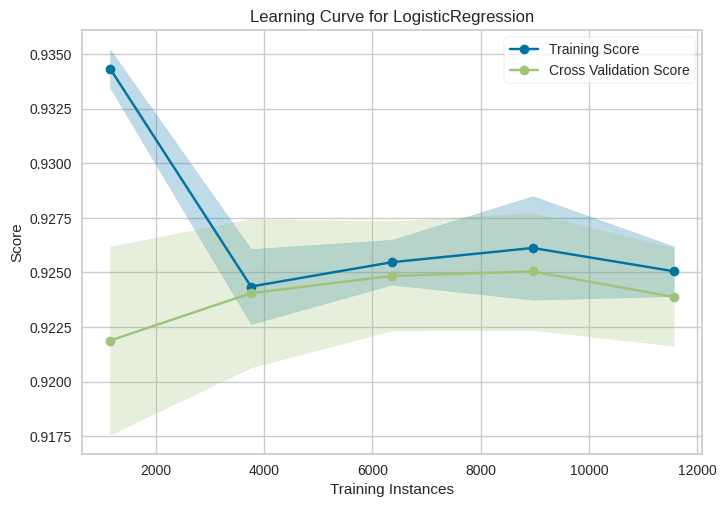

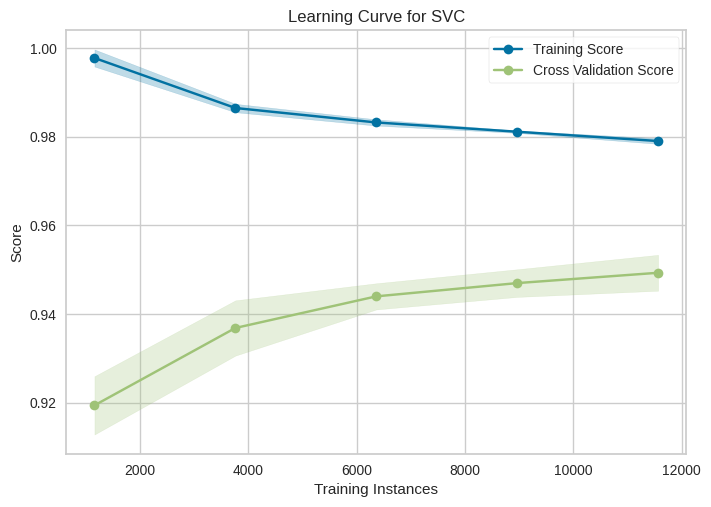

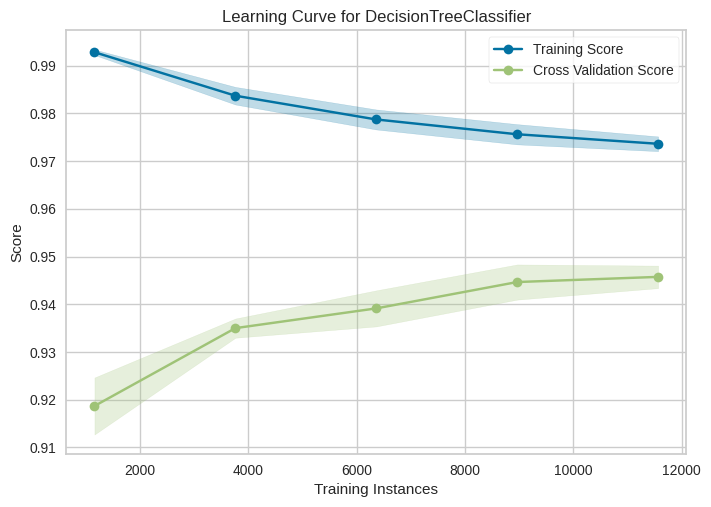

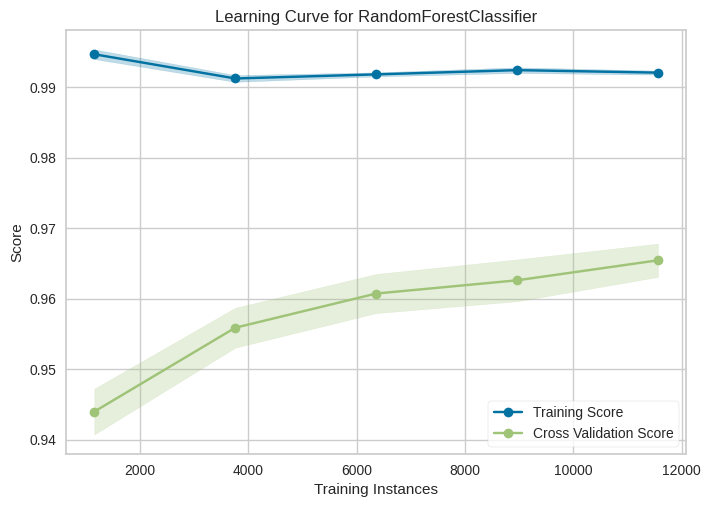

<Axes: title={'center': 'Learning Curve for RandomForestClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [ ]:
visualizer1 = LearningCurve(grid_log.best_estimator_, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer1.fit(X_train, y_train)

# Finalize and render the figure
visualizer1.show()

visualizer2 = LearningCurve(grid_svc.best_estimator_, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer2.fit(X_train, y_train)

# Finalize and render the figure
visualizer2.show()

visualizer3 = LearningCurve(grid_tree.best_estimator_, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer3.fit(X_train, y_train)

# Finalize and render the figure
visualizer3.show()

visualizer4 = LearningCurve(grid_rf.best_estimator_, scoring='f1', cv=5, n_jobs=-1)

# Fit the data to the visualizer
visualizer4.fit(X_train, y_train)

# Finalize and render the figure
visualizer4.show()

---

### Post-Tuning Analysis: Reading the New Curves

Now that we have tuned our hyperparameters and regenerated our Learning Curves, you likely noticed that the results didn't just "go up" across the board. In some cases, the lines moved down, or didn't move at all!

This is exactly what we wanted to see. Here is the breakdown of what these visual changes actually mean for the health of our models.

**1. Logistic Regression: The "Linear Ceiling"**

* The Observation: You likely saw very little change in this graph. The Training and Validation lines probably remained converged but stuck at the same accuracy level as before.

* The Diagnosis: This "stubbornness" is an important finding. It proves that our dataset is non-linear. Logistic Regression tries to separate "Phishing" from "Safe" using a straight line. No matter how much we tune the regularization parameters, a straight line cannot perfectly separate complex, curved data patterns. We have hit the mathematical limit of this algorithm.

**2. SVC (Support Vector Classifier): The "Non-Linear Awakening"**

* The Observation: This model likely showed the most dramatic improvement. In the first lab, it performed similarly to Logistic Regression (underfitting). Now, the Validation (green) line has likely climbed significantly higher.

* The Diagnosis: By switching from a linear kernel to an rbf (non-linear) kernel, we gave the model the ability to draw curved decision boundaries. It stopped treating the data like a flat plane and started learning the complex nuances of the dataset, breaking through the ceiling that stopped the Logistic Regression model.

**3. Decision Tree: The "Safety Check"**

* The Observation: Look closely at the Blue Line (Training Score). In the first lab, it was a flat line at the very top (1.0 or near-perfect). Now, it has likely dropped slightly.

* The Diagnosis: A lower training score is actually a success here! The original tree was "memorizing" the data (overfitting). By limiting the max_depth, we forced the tree to stop memorizing noise and outliers. We sacrificed a tiny bit of training accuracy to gain a model that is safer and more generalizable for the real world.

**4. Random Forest: The "Stabilized Champion"**

* The Observation: Like the Decision Tree, the training score (blue line) may have dipped slightly from perfection, while the validation score (green line) remained high or improved slightly.

* The Diagnosis: This model remains our strongest performer. The tuning helped narrow the gap between the blue and green lines. This indicates we have successfully reduced variance (overfitting) while maintaining the high power of the ensemble method.

##⚠️ CRITICAL WARNING: Do Not Manually Scale!

**Read this before running the final test.**

In previous labs, you might have manually scaled your data like this:

Python
**THE OLD WAY (Do NOT do this now)**
```python
X_test_scaled = scaler.transform(X_test)
model.predict(X_test_scaled)
```
However, we are now using Pipelines. Our best_estimator_ pipeline contains the scaler inside it. When you call .predict(X_test), the pipeline automatically scales the data for you.

If you pass raw data: The pipeline scales it → Correct Result.

If you pass scaled data: The pipeline scales it again (Double Scaling) → Incorrect Result.

Rule: Pass the original, unscaled X_test into the pipeline

###Deep Dive: How the Pipeline "Thinks"

A Pipeline is not just a list of steps; it is a smart workflow manager that knows the difference between Training (Learning) and Testing (Applying).

It changes its behavior based on which command you call.

**Scenario A: The Training Phase (.fit())**

Goal: Learn patterns, normalize data, and fix imbalance.

When we call grid_search.fit(X_train, y_train), the data flows through the pipeline like this:

1. Step 1: The Scaler (fit_transform)

* The Scaler looks at the training data, calculates the Mean and Standard Deviation, and transforms the data to be "standard."

* Result: Scaled Training Data.

2. Step 2: SMOTE (fit_resample)

* The Critical Step: SMOTE looks at the minority class and generates synthetic (fake) examples to balance the dataset.

* Result: A larger, perfectly balanced, scaled dataset.

3. Step 3: The Model (fit)

* The model (e.g., Random Forest) trains on this balanced, scaled data. It learns to recognize the minority class because SMOTE gave it enough examples to study.

**Scenario B: The Prediction Phase (.predict())**

Goal: Apply what we learned to real-world data.

When we call best_estimator_.predict(X_test), the pipeline changes its path. It knows that X_test is real data that we must not tamper with.

1. Step 1: The Scaler (transform)

* Crucial Difference: It does not calculate a new Mean/Std Dev. It uses the "Training Mean" it learned in Scenario A.

* Result: Test data that is scaled exactly like the training data.

2. Step 2: SMOTE (SKIPPED!)

* The Smart Switch: The pipeline bypasses SMOTE entirely. We do not want to generate fake data for the test set. We want to know how the model performs on real, imbalanced data.

3. Step 3: The Model (predict)

* The model takes the scaled (but not SMOTEd) test data and outputs a prediction.

Why is this important?

* If you didn't use a pipeline and tried to do this manually, you would have to write complex if/else logic to ensure you didn't accidentally SMOTE your test set or re-fit your Scaler.

# Phase 3: The Final Model "Bake-Off"
Now that we have finished running GridSearchCV on all four algorithms, we have a collection of results. But how do we use them?

**1. Understanding the best_estimator_**

Think of GridSearchCV not just as a model, but as a Tournament Director.

1. The Contestants: For each algorithm, you entered several different settings (e.g., C=1, C=10, C=100).

2. The Event: The director trained and cross-validated every single version.

3. The Winner: The version with the highest score is saved as the best_estimator_.

Crucially, once the winner is found, Scikit-Learn automatically retrains that specific model on the entire training set (not just the validation folds). This means best_estimator_ is a fully optimized pipeline, trained on all your data, ready to make predictions.

**2. Extracting the "Champions"**

We will now extract the winning pipeline for each algorithm and store them in a dictionary. This creates a "Hall of Fame" of our best models, making it easy to loop through them for the final test.

---

```python
# Create a dictionary to store our best trained pipelines
best_pipelines = {
    "Logistic Regression": grid_log.best_estimator_,
    "SVC": grid_svc.best_estimator_,
    "Decision Tree": grid_tree.best_estimator_,
    "Random Forest": grid_rf.best_estimator_
}

# Verify that we have extracted the pipelines
print("--- Champions Selected ---")
for name, pipe in best_pipelines.items():
    print(f"{name}: Ready")
```

**3. The Final Evaluation**

This is the moment of truth. We will now run our four "Champions" against the Test Set (X_test, y_test).

Important Reminder:

* Scaling: We do not need to manually scale X_test. Our pipelines contain a StandardScaler step that will handle this automatically.

* Data Leakage: We do not SMOTE the test set. Our pipelines are smart enough to skip the SMOTE step during prediction.


```python
from sklearn.metrics import classification_report, accuracy_score

print("--- FINAL TEST RESULTS (UNSEEN DATA) ---")

for name, pipeline in best_pipelines.items():
    print(f"\nModel: {name}")
    
    # 1. Predict directly on X_test
    # The pipeline automatically scales the data, skips SMOTE, and predicts
    y_pred = pipeline.predict(X_test)
    
    # 2. Score the model
    # We print the Accuracy and the full Classification Report
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-" * 60)

```

In [ ]:
# Create a dictionary to store our best trained pipelines
best_pipelines = {
    "Logistic Regression": grid_log.best_estimator_,
    "SVC": grid_svc.best_estimator_,
    "Decision Tree": grid_tree.best_estimator_,
    "Random Forest": grid_rf.best_estimator_
}

# Verify that we have extracted the pipelines
print("--- Champions Selected ---")
for name, pipe in best_pipelines.items():
    print(f"{name}: Ready")

--- Champions Selected ---
Logistic Regression: Ready
SVC: Ready
Decision Tree: Ready
Random Forest: Ready


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("--- FINAL TEST RESULTS (UNSEEN DATA) ---")

for name, pipeline in best_pipelines.items():
    print(f"\nModel: {name}")

    # 1. Predict directly on X_test
    # The pipeline automatically scales the data, skips SMOTE, and predicts
    y_pred = pipeline.predict(X_test)

    # 2. Score the model
    # We print the Accuracy and the full Classification Report
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

--- FINAL TEST RESULTS (UNSEEN DATA) ---

Model: Logistic Regression
Accuracy: 0.9020
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1122
           1       0.95      0.91      0.93      2492

    accuracy                           0.90      3614
   macro avg       0.88      0.90      0.89      3614
weighted avg       0.91      0.90      0.90      3614

------------------------------------------------------------

Model: SVC
Accuracy: 0.9314
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1122
           1       0.96      0.94      0.95      2492

    accuracy                           0.93      3614
   macro avg       0.92      0.93      0.92      3614
weighted avg       0.93      0.93      0.93      3614

------------------------------------------------------------

Model: Decision Tree
Accuracy: 0.9336
              precision    recall  f1-score   support

           0   

### Analysis Questions

The Baseline Check: Did any of the complex models (Random Forest, SVM) perform worse than the simple Logistic Regression? If so, why might that be?

**[insert answer]**

The Random Forest vs. Decision Tree: Random Forests are essentially a collection of many Decision Trees. Did the Random Forest outperform the single Decision Tree? Why do you think that is?

**[insert answer]**


The Winner: Based on the F1-Scores and the detailed reports (Precision/Recall), which model would you choose to deploy in a real security system?

**[insert answer]**


---
 # Module 3: Summary and Integration

This module has guided us through a professional, iterative workflow for building robust and trustworthy machine learning models, particularly in the challenging context of cybersecurity. We've moved beyond basic model building to master critical skills essential for real-world threat detection. Let's recap how each step contributes to our ultimate goal of finding the 'best model for the job' and how they integrate into a cohesive strategy.



### 1. Visual Analysis: Exploratory Data Analysis (EDA)

**Contribution:** Our journey began with powerful visualization tools like **Matplotlib** and **Seaborn**. EDA is our 'eyes' into the data, allowing us to:
*   **Understand Distributions:** Histograms and Box Plots revealed the shape, spread, and potential outliers within our numerical features (`time_domain_activation`, `qty_dot_url`, `qty_slash_url`). This informed us about potential data cleaning needs and feature characteristics.
*   **Identify Class Imbalance:** Crucially, count plots vividly demonstrated the severe class imbalance in our `phishing` target variable, highlighting the prevalent 'Accuracy Trap' in cybersecurity datasets.

**Integration:** EDA is the foundational step. It informs subsequent data cleaning, preprocessing, and model selection decisions, preventing us from blindly applying algorithms to flawed data.

### 2. Data Cleaning and Preprocessing

**Contribution:** We systematically addressed common data quality issues to ensure our models are trained on reliable information:
*   **Handling Missing Values:** Replacing placeholder `-1` values with `np.nan` and then deciding how to manage features or rows with missing data.
*   **Removing Duplicates:** Ensuring each observation is unique.
*   **Eliminating Zero-Variance Features:** Removing features that provide no information because they have only one unique value.

**Integration:** A clean dataset is paramount for accurate model training. These steps directly improve the quality of the data before any predictive analysis begins.

### 3. Train-Test Split

**Contribution:** This was a critical procedural step performed *before* any further preprocessing or model training:
*   **Preventing Data Leakage:** By splitting the data into `train_df` and `test_df` early, we ensured that information from the unseen test set did not inadvertently influence our training process.
*   **Unbiased Evaluation:** The test set provides a truly independent measure of our model's ability to generalize to new data.

**Integration:** The train-test split establishes the integrity of our entire machine learning pipeline. All subsequent preprocessing (scaling, SMOTE) is fit *only* on the training data and then applied to both sets, maintaining a rigorous evaluation framework.

### 4. Correlation Analysis and Feature Selection

**Contribution:** We explored relationships within our data:
*   **Target Correlation:** Identifying features most strongly related to the `phishing` target variable (both linearly via Pearson and monotonically via Spearman). These are our strongest potential predictors.
*   **Feature Pair Correlation:** Identifying highly correlated feature pairs to address **multicollinearity**. Our automated feature selection process intelligently removed redundant features by keeping the one with stronger correlation to the target.

**Integration:** This process streamlines our model by reducing dimensionality and removing redundant information, potentially leading to simpler, more stable, and more interpretable models without sacrificing predictive power. It directly feeds into model training by providing an optimized feature set.

### 5. Deep Dive on Model Metrics

**Contribution:** We moved beyond the deceptive simplicity of 'Accuracy' to embrace more robust metrics:
*   **Confusion Matrix:** The foundational tool for understanding True Positives, True Negatives, False Positives, and False Negatives.
*   **Precision, Recall, F1-Score:** Crucial for imbalanced datasets, allowing us to assess the cost of false alarms vs. missed threats.
*   **ROC-AUC:** A comprehensive measure of a model's overall discriminative power, independent of a specific threshold.

**Integration:** These metrics are essential for correctly evaluating our models, especially in high-stakes security contexts where the cost of a False Negative (missed attack) can be catastrophic. They guide our hyperparameter tuning and final model selection.

### 6. Addressing Class Imbalance: SMOTE and Undersampling

**Contribution:** We tackled the 'Accuracy Trap' head-on:
*   **SMOTE (Synthetic Minority Over-sampling Technique):** This intelligent oversampling method generated synthetic examples of our minority class (non-phishing) to balance the training dataset. This forced our models to learn the patterns of the rare class.
*   **Undersampling:** While explored, we recognized its limitation in discarding valuable majority-class data.

**Integration:** Balancing the training data is a prerequisite for building effective models on imbalanced datasets. It ensures that our models learn to identify both classes, not just the majority, directly impacting our ability to detect actual threats.

### 7. Diagnosing and Correcting Underfitting and Overfitting

**Contribution:** We learned to diagnose and mitigate two common model pathologies:
*   **Learning Curves:** Visualizing training and cross-validation scores helped us identify models that were either too simple (underfitting) or too complex (overfitting).
*   **Hyperparameter Tuning with GridSearchCV:** We systematically adjusted model 'knobs' (e.g., `C`, `kernel`, `max_depth`, `n_estimators`) within an `ImbPipeline` to find the optimal balance between bias and variance.
*   **Pipelines:** Crucially, the use of `ImbPipeline` ensured that scaling and SMOTE were applied correctly and consistently throughout our tuning and evaluation, preventing data leakage and ensuring fair comparisons.

**Integration:** This iterative process of diagnosis and tuning is central to building generalizable models. It refines the chosen algorithms to perform optimally on our specific dataset, ensuring they learn the true underlying patterns rather than noise.

### 8. Final Model Bake-Off and Selection

**Contribution:** The culmination of our efforts involved evaluating our best-tuned models on the completely unseen test set:
*   **Unbiased Performance:** By extracting the `best_estimator_` from `GridSearchCV` and evaluating it on `X_test`, we obtained realistic performance metrics.
*   **Comparative Analysis:** We compared the F1-scores, precision, and recall of different algorithms (Logistic Regression, SVC, Decision Tree, Random Forest) to determine which model was the most suitable for detecting phishing URLs.

**Integration:** This final step validates our entire workflow. It confirms that our feature engineering, data balancing, and model tuning efforts have resulted in a model that can effectively identify threats in new, real-world data, directly addressing our module's objective of building robust and trustworthy security models.

---

**Overall Goal Achieved:** Through this module, we have established a comprehensive and professional machine learning workflow. We learned to analyze data critically, measure model performance accurately, address common data challenges like imbalance, and systematically optimize various advanced models. This systematic approach ensures that the models we build are not just 'accurate' on paper but are genuinely effective, reliable, and actionable for real-world cybersecurity applications.

##Sources:

* https://www.geeksforgeeks.org/python/how-to-make-histograms-with-density-plots-with-seaborn-histplot/

* https://medium.com/image-processing-with-python/theoretical-basis-of-ml-model-evaluation-metrics-summary-3cae19129679

* Learning material provided by Dr. ismail.

* Valuble insight and guidence provided by Maraz Mia.

* https://neptune.ai/blog/building-ml-model-training-pipeline
